# Tarification automobile : comprendre et modéliser la gravité

**Notre rôle : estimer le montant attendu sachant qu’un sinistre survient.** Le modèle de fréquence est développé séparément par notre partenaire.

$$g(x)=E[S\mid S>0,X=x], \qquad \text{prime pure}(x)=p(x)\times g(x).$$

Un montant prédit de 2 000 € ne constitue donc pas une prime de 2 000 €. Avec une probabilité de 5 %, la prime pure serait de 100 €.

**Périmètre :** aucun modèle de fréquence, aucune soumission Kaggle automatique. Tout le code métier est contenu dans ce notebook. Les CSV produits sont des résultats destinés au partenaire.

**Précision géographique :** l’analyse demandée concerne le département, dérivé du code détaillé `code_postal`. Voir le complément départemental, distinct de l’audit des codes à cinq caractères.

**Version actuelle : sélection de variables exclusivement pour Gamma, comparaison sur cinq plis clients et validation croisée imbriquée. Le bloc final charge la configuration gagnante et sauvegarde une pipeline complète, vérifiée dans un nouveau processus.**

## 1. Environnement et reproductibilité

Nous utilisons pandas/numpy pour les données, matplotlib pour les figures et scikit-learn pour les pipelines et modèles. Une graine fixe rend la séparation et les modèles reproductibles. Limiter les threads évite de saturer la machine. Les versions affichées permettent d’expliquer une éventuelle différence entre deux exécutions.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['OPENBLAS_NUM_THREADS'] = '2'
os.environ['MKL_NUM_THREADS'] = '2'
from pathlib import Path
import sys, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import GammaRegressor
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_gamma_deviance
from sklearn.inspection import permutation_importance
from threadpoolctl import threadpool_limits
threadpool_limits(limits=2)
SEED = 42
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
pd.set_option('display.max_columns', 40)
print({'Python': platform.python_version(), 'pandas': pd.__version__, 'numpy': np.__version__, 'sklearn': sklearn.__version__})
# Trouver les données sans dépendre d’un chemin absolu propre à une machine.
candidates = [Path.cwd(), Path.cwd() / 'TD-Tarification-automobile-par-Machine-Learning']
ROOT = next((p for p in candidates if (p / 'Data/train.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Exécuter depuis la racine du dépôt ou son dossier parent.')
OUTPUT = ROOT / 'output' / 'gravite'
print('Racine du projet :', ROOT)

/home/cytech/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


{'Python': '3.12.3', 'pandas': '3.0.6', 'numpy': '2.5.3', 'sklearn': '1.9.1'}
Racine du projet : /data/cours/Data Science/Project/TD-Tarification-automobile-par-Machine-Learning


## 2. Que représentent train.csv et test.csv ?

`train.csv` contient les caractéristiques connues et les résultats observés ; il sert à apprendre et à évaluer localement. `test.csv` contient les prospects à prédire, sans résultats observés : il ne permet donc pas de mesurer une erreur.

Une ligne décrit un **contrat associé à un véhicule**, pas nécessairement un client unique. Plusieurs contrats peuvent appartenir au même client. Le champ `index` sera conservé pour l’alignement des prédictions, mais jamais utilisé comme prédicteur. Le nom `nombre_sinistres` pourrait suggérer un comptage ; nous vérifions ses valeurs réelles au lieu de supposer qu’il représente une fréquence annuelle.

Nous lisons le code géographique comme du texte pour préserver les zéros initiaux. Sans dictionnaire de données, nous ne supposons pas que `code_postal` est effectivement un code postal plutôt qu’un code de commune.

In [2]:
train = pd.read_csv(ROOT / 'Data/train.csv', dtype={'code_postal': str})
test = pd.read_csv(ROOT / 'Data/test.csv', dtype={'code_postal': str})
TARGET = 'montant_sinistre'
CLAIM = 'nombre_sinistres'
print('Dimensions train :', train.shape, '| test :', test.shape)
display(train.head(3), test.head(3))
only_train = sorted(set(train) - set(test))
only_test = sorted(set(test) - set(train))
print('Colonnes uniquement dans train :', only_train)
print('Colonnes uniquement dans test :', only_test)
assert {TARGET, CLAIM, 'id_client', 'id_vehicule', 'id_contrat'} == set(only_train)
assert not only_test
assert train['index'].is_unique and test['index'].is_unique
assert set(train['index']).isdisjoint(set(test['index']))
print('Plages index :', (train['index'].min(), train['index'].max()), (test['index'].min(), test['index'].max()))
print('Doublons de contrats :', train.id_contrat.duplicated().sum())
print('Lignes supplémentaires pour des clients déjà présents :', train.id_client.duplicated().sum())
print('Doublons exacts train/test :', train.duplicated().sum(), test.duplicated().sum())

Dimensions train : (50000, 33) | test : (50000, 28)


,index,id_client,id_vehicule,id_contrat,bonus,type_contrat,duree_contrat,anciennete_info,freq_paiement,paiement,utilisation,code_postal,conducteur2,age_conducteur1,age_conducteur2,sex_conducteur1,sex_conducteur2,anciennete_permis1,anciennete_permis2,anciennete_vehicule,cylindre_vehicule,din_vehicule,essence_vehicule,marque_vehicule,modele_vehicule,debut_vente_vehicule,fin_vente_vehicule,vitesse_vehicule,type_vehicule,prix_vehicule,poids_vehicule,nombre_sinistres,montant_sinistre
0,0,A00000001,V01,A00000001-V01,0.5,Maxi,29,9,Biannual,No,Retired,36233,No,85,0,M,NaN,62,0,10.0,1587,98,Gasoline,PEUGEOT,306,10,9,182,Tourism,20700,1210,0,0.0
1,1,A00000002,V01,A00000002-V01,0.5,Maxi,3,1,Biannual,No,Retired,92073,No,69,0,M,NaN,39,0,4.0,2149,170,Diesel,MERCEDES BENZ,C220,4,2,229,Tourism,34250,1510,0,0.0
2,2,A00000003,V01,A00000003-V01,0.5,Maxi,2,2,Yearly,No,WorkPrivate,92026,No,37,0,M,NaN,18,0,11.0,1991,150,Gasoline,BMW,Z3,12,11,210,Tourism,28661,1270,0,0.0


,index,bonus,type_contrat,duree_contrat,anciennete_info,freq_paiement,paiement,utilisation,code_postal,conducteur2,age_conducteur1,age_conducteur2,sex_conducteur1,sex_conducteur2,anciennete_permis1,anciennete_permis2,anciennete_vehicule,cylindre_vehicule,din_vehicule,essence_vehicule,marque_vehicule,modele_vehicule,debut_vente_vehicule,fin_vente_vehicule,vitesse_vehicule,type_vehicule,prix_vehicule,poids_vehicule
0,50000,0.58,Maxi,1,1,Yearly,No,Retired,28388,No,66,0,F,NaN,34,0,16.0,1239,55,Gasoline,RENAULT,CLIO,16,15,150,Tourism,10321,830
1,50001,0.50,Median2,2,2,Yearly,No,Retired,19123,No,68,0,M,NaN,48,0,15.0,2155,96,Diesel,MERCEDES BENZ,C220,16,12,175,Tourism,24652,1400
2,50002,0.76,Maxi,10,2,Biannual,No,WorkPrivate,77183,No,43,0,M,NaN,22,0,2.0,1598,90,Diesel,VOLKSWAGEN,POLO,2,1,180,Tourism,16280,1082


Colonnes uniquement dans train : ['id_client', 'id_contrat', 'id_vehicule', 'montant_sinistre', 'nombre_sinistres']
Colonnes uniquement dans test : []
Plages index : (0, 49999) (50000, 99999)
Doublons de contrats : 0
Lignes supplémentaires pour des clients déjà présents : 4215


Doublons exacts train/test : 0 0


### Dictionnaire de lecture et disponibilité

- **Cibles :** `nombre_sinistres` permet de sélectionner les sinistrés ; `montant_sinistre` est la cible de régression. Ces deux colonnes sont interdites en entrée du modèle.
- **Identifiants :** `index`, `id_client`, `id_vehicule`, `id_contrat` servent à repérer ou regrouper les lignes. Les trois derniers sont absents du test et ne peuvent pas servir à prédire.
- **Contrat :** `bonus`, `type_contrat`, `duree_contrat`, `anciennete_info`, `freq_paiement`, `paiement`, `utilisation` décrivent la relation ou l’usage. Les unités des durées et le sens exact de `paiement` doivent être confirmés.
- **Conducteurs :** `conducteur2`, âges, sexes, anciennetés de permis. Les zéros du second conducteur peuvent signifier son absence.
- **Véhicule :** ancienneté, cylindrée, puissance (`din_vehicule`), énergie, marque, modèle, dates/anciennetés de commercialisation, vitesse, type, prix et poids. Les unités et codages doivent être confirmés avant une interprétation métier précise.
- **Géographie :** `code_postal`, catégorie à forte cardinalité.

**Risque de fuite temporelle :** être présent dans le test ne prouve pas qu’un champ soit disponible avant le sinistre. Nous conservons les caractéristiques contractuelles communes sous cette hypothèse, à confirmer avec le fournisseur des données. Nous ne convertissons pas `duree_contrat` en exposition annuelle : l’horizon et les unités ne sont pas documentés.

**Sexe :** les deux colonnes sont auditées mais exclues des modèles par choix métier prudent, cohérent avec le point soulevé dans l’énoncé. Les autres variables peuvent néanmoins porter des informations corrélées ; leur retrait ne constitue pas une garantie complète d’équité.

In [3]:
common = [c for c in test if c != 'index']
audit = pd.DataFrame({
    'type_train': train.dtypes.astype(str),
    'type_test': test.dtypes.astype(str),
    'uniques_train': train.nunique(),
    'manquants_train_%': train.isna().mean().mul(100),
    'manquants_test_%': test.isna().mean().mul(100),
})
display(audit.round(3))
display(train.select_dtypes('number').describe(percentiles=[.01, .5, .99]).T.round(2))
quality = []
for name, df in [('train', train), ('test', test)]:
    quality.append({
        'fichier': name,
        'poids_zero': (df.poids_vehicule == 0).sum(),
        'cylindree_zero': (df.cylindre_vehicule == 0).sum(),
        'permis1_superieur_age': (df.anciennete_permis1 > df.age_conducteur1).sum(),
        'permis2_superieur_age': ((df.conducteur2 == 'Yes') & (df.anciennete_permis2 > df.age_conducteur2)).sum(),
        'sexe2_absent_sans_conducteur2': ((df.conducteur2 == 'No') & df.sex_conducteur2.isna()).sum(),
        'sexe2_absent_avec_conducteur2': ((df.conducteur2 == 'Yes') & df.sex_conducteur2.isna()).sum(),
    })
display(pd.DataFrame(quality).set_index('fichier'))

,type_train,type_test,uniques_train,manquants_train_%,manquants_test_%
age_conducteur1,int64,int64,83,0.000,0.000
age_conducteur2,int64,int64,81,0.000,0.000
anciennete_info,int64,int64,25,0.000,0.000
anciennete_permis1,int64,int64,79,0.000,0.000
anciennete_permis2,int64,int64,71,0.000,0.000
anciennete_vehicule,float64,float64,63,0.002,0.000
bonus,float64,float64,73,0.000,0.000
code_postal,str,str,12790,0.000,0.000
conducteur2,str,str,2,0.000,0.000
cylindre_vehicule,int64,int64,532,0.000,0.000


,count,mean,std,min,1%,50%,99%,max
index,50000.0,24999.50,14433.90,0.0,499.99,24999.5,49499.01,49999.00
bonus,50000.0,0.54,0.10,0.5,0.50,0.5,0.95,2.16
duree_contrat,50000.0,11.09,8.57,1.0,1.00,9.0,31.00,41.00
anciennete_info,50000.0,2.73,2.35,1.0,1.00,2.0,12.00,25.00
age_conducteur1,50000.0,54.65,14.87,19.0,24.00,54.0,86.00,101.00
age_conducteur2,50000.0,15.57,23.99,0.0,0.00,0.0,78.00,99.00
anciennete_permis1,50000.0,32.44,13.47,1.0,4.00,32.0,61.00,111.00
anciennete_permis2,50000.0,9.14,17.06,0.0,0.00,0.0,59.00,111.00
anciennete_vehicule,49999.0,9.53,7.01,1.0,1.00,8.0,33.00,65.00
cylindre_vehicule,50000.0,1647.80,463.65,0.0,652.00,1587.0,2993.00,6997.00


,poids_zero,cylindree_zero,permis1_superieur_age,permis2_superieur_age,sexe2_absent_sans_conducteur2,sexe2_absent_avec_conducteur2
fichier,,,,,,
train,1883,3,12,397,33406,0
test,1861,2,14,371,33408,0


### Politique de traitement des anomalies

Les poids et cylindrées à zéro sont remplacés par des valeurs manquantes, puis imputés dans la pipeline ; ce choix reste une hypothèse faute de dictionnaire. Une ancienneté de permis supérieure à l’âge est également mise à manquant. Nous n’imposons pas de seuil d’âge légal spécifique au permis, dont l’unité et la catégorie ne sont pas confirmées.

Pour le second conducteur, les zéros sont conservés quand `conducteur2 == 'No'` : ils représentent une absence structurelle, déjà indiquée par cette variable. Les valeurs extrêmes plausibles (véhicules coûteux, conducteurs âgés, gros sinistres) sont conservées. Ces règles sont fixes et indépendantes de la cible ; les statistiques d’imputation sont apprises seulement sur l’ensemble d’apprentissage.

## 3. Les deux fichiers décrivent-ils des populations comparables ?

Nous comparons les caractéristiques, jamais des cibles inconnues du test. Pour les variables numériques, le déplacement standardisé de la moyenne mesure la différence en unités d’écart-type du train. Pour les catégories, la distance de variation totale vaut 0 pour des distributions identiques et 1 pour des distributions disjointes.

Ces indicateurs sont descriptifs : ils ne prouvent ni stabilité temporelle ni différence significative. Les modalités absentes des **sinistrés d’apprentissage** seront également contrôlées plus loin, car ce sous-ensemble est beaucoup plus petit que le train complet.

,moyenne_train,moyenne_test,mediane_train,mediane_test,deplacement_standardise
bonus,0.538,0.537,0.5,0.5,-0.012
din_vehicule,91.548,91.237,87.0,87.0,-0.009
prix_vehicule,18095.562,18021.821,16250.0,16200.0,-0.008
cylindre_vehicule,1647.796,1643.971,1587.0,1587.0,-0.008
anciennete_permis1,32.445,32.535,32.0,33.0,0.007
debut_vente_vehicule,11.628,11.679,10.0,10.0,0.007
fin_vente_vehicule,8.653,8.693,7.0,7.0,0.006
anciennete_vehicule,9.531,9.573,8.0,8.0,0.006
anciennete_info,2.727,2.740,2.0,2.0,0.006
poids_vehicule,1129.088,1127.327,1130.0,1125.0,-0.005


,variable,distance_variation_totale,modalites_nouvelles_test,lignes_test_modalite_inconnue_%
4,code_postal,0.305,5004,14.964
10,modele_vehicule,0.045,137,0.412
9,marque_vehicule,0.011,12,0.038
1,freq_paiement,0.005,0,0.000
0,type_contrat,0.004,0,0.000
3,utilisation,0.003,0,0.000
7,sex_conducteur2,0.002,0,0.000
8,essence_vehicule,0.002,0,0.000
11,type_vehicule,0.002,0,0.000
6,sex_conducteur1,0.000,0,0.000


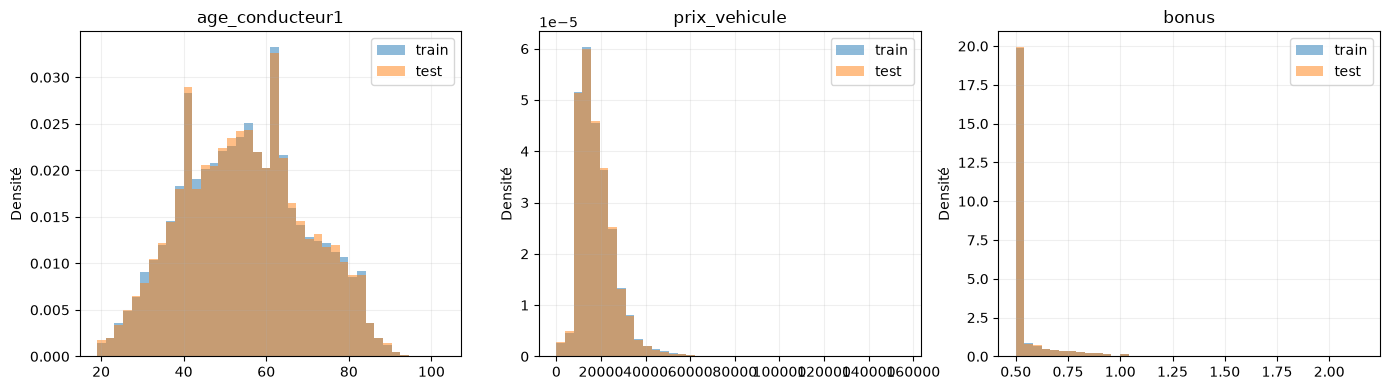

In [4]:
cat_raw = [c for c in common if not pd.api.types.is_numeric_dtype(train[c])]
num_raw = [c for c in common if c not in cat_raw]
shift_num = pd.DataFrame({
    'moyenne_train': train[num_raw].mean(), 'moyenne_test': test[num_raw].mean(),
    'mediane_train': train[num_raw].median(), 'mediane_test': test[num_raw].median(),
    'deplacement_standardise': (test[num_raw].mean()-train[num_raw].mean()) / train[num_raw].std().replace(0, np.nan)
})
display(shift_num.reindex(shift_num.deplacement_standardise.abs().sort_values(ascending=False).index).round(3))
shift_cat = []
for col in cat_raw:
    a = train[col].fillna('__ABSENT__').value_counts(normalize=True)
    b = test[col].fillna('__ABSENT__').value_counts(normalize=True)
    keys = a.index.union(b.index)
    shift_cat.append({'variable': col, 'distance_variation_totale': .5 * (a.reindex(keys, fill_value=0)-b.reindex(keys, fill_value=0)).abs().sum(),
                      'modalites_nouvelles_test': len(set(b.index)-set(a.index)),
                      'lignes_test_modalite_inconnue_%': 100 * (~test[col].fillna('__ABSENT__').isin(a.index)).mean()})
display(pd.DataFrame(shift_cat).sort_values('distance_variation_totale', ascending=False).round(3))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['age_conducteur1', 'prix_vehicule', 'bonus']):
    bins = np.histogram_bin_edges(pd.concat([train[col], test[col]]).dropna(), bins=40)
    ax.hist(train[col].dropna(), bins=bins, density=True, alpha=.5, label='train')
    ax.hist(test[col].dropna(), bins=bins, density=True, alpha=.5, label='test')
    ax.set(title=col, ylabel='Densité'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Comprendre notre cible : uniquement les contrats sinistrés

Avant de filtrer, vérifions que les zéros de coût correspondent à l’absence de sinistre. Le filtre d’apprentissage sera `nombre_sinistres > 0`. Il ne sera jamais utilisé sur le test : notre modèle doit prédire un montant conditionnel pour **tous** les prospects, même ceux qui n’auront probablement pas de sinistre.

La moyenne de gravité est calculée sur les sinistrés ; la moyenne sur tout le portefeuille est une moyenne de coût, qui inclut la fréquence. Les confondre ferait intervenir deux fois la probabilité de sinistre lors du calcul de la prime.

,effectif
nombre_sinistres,
0,47083
1,2917


,montant_euros
count,2917.00
mean,1771.84
std,1463.95
min,600.60
1%,612.51
25%,959.97
50%,1236.00
75%,2169.10
90%,3336.74
95%,4355.26


Taux de contrats sinistrés : 5.83%
Gravité moyenne : 1,771.84 € ; médiane : 1,236.00 €
Coût moyen de tout le portefeuille : 103.37 €
Part du coût portée par les montants >= P99 : 5.96%
Montants les plus répétés (hypothèse de forfaits ou de codage, à confirmer) :


,effectif
montant_sinistre,
1236.00,333
1010.41,128
2683.76,44
618.00,31
1442.87,30
1240.89,18
2453.28,17
2323.95,12
3288.46,8


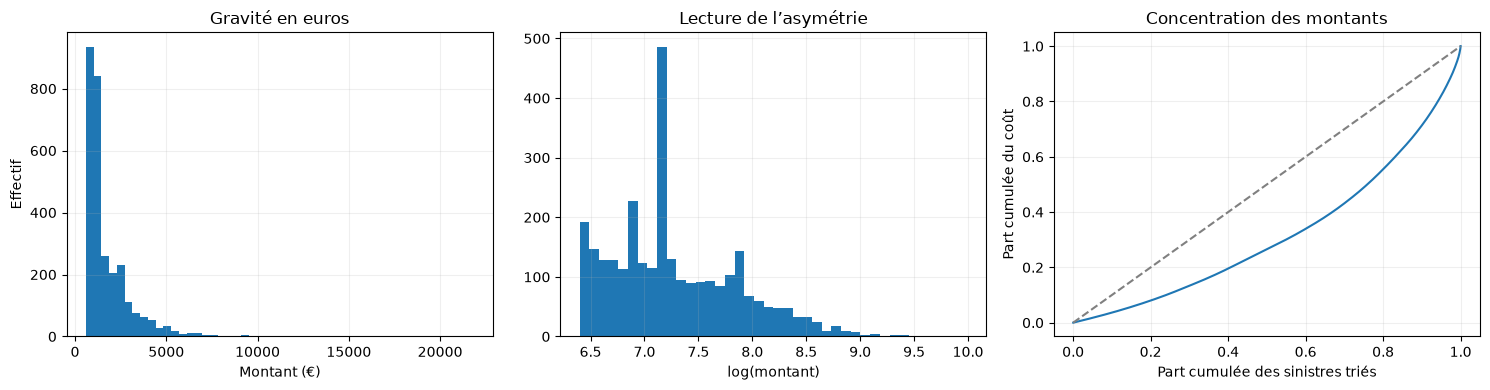

In [5]:
assert train[[CLAIM, TARGET]].notna().all().all()
assert np.isfinite(train[TARGET]).all() and train[TARGET].ge(0).all()
assert train.loc[train[CLAIM] == 0, TARGET].eq(0).all()
assert train.loc[train[CLAIM] > 0, TARGET].gt(0).all()
claims = train.loc[train[CLAIM] > 0].copy()
display(train[CLAIM].value_counts().sort_index().rename_axis('nombre_sinistres').to_frame('effectif'))
display(claims[TARGET].describe(percentiles=[.01, .25, .5, .75, .9, .95, .99]).to_frame('montant_euros').round(2))
threshold = claims[TARGET].quantile(.99)
print(f'Taux de contrats sinistrés : {len(claims)/len(train):.2%}')
print(f'Gravité moyenne : {claims[TARGET].mean():,.2f} € ; médiane : {claims[TARGET].median():,.2f} €')
print(f'Coût moyen de tout le portefeuille : {train[TARGET].mean():,.2f} €')
print(f'Part du coût portée par les montants >= P99 : {claims.loc[claims[TARGET]>=threshold, TARGET].sum()/claims[TARGET].sum():.2%}')
print('Montants les plus répétés (hypothèse de forfaits ou de codage, à confirmer) :')
display(claims[TARGET].value_counts().head(10).to_frame('effectif'))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(claims[TARGET], bins=50); axes[0].set(xlabel='Montant (€)', ylabel='Effectif', title='Gravité en euros')
axes[1].hist(np.log(claims[TARGET]), bins=40); axes[1].set(xlabel='log(montant)', title='Lecture de l’asymétrie')
sorted_y = np.sort(claims[TARGET].to_numpy())
axes[2].plot(np.arange(1,len(sorted_y)+1)/len(sorted_y), np.cumsum(sorted_y)/sorted_y.sum())
axes[2].plot([0,1],[0,1], '--', color='grey'); axes[2].set(xlabel='Part cumulée des sinistres triés', ylabel='Part cumulée du coût', title='Concentration des montants')
plt.tight_layout(); plt.show()

### Pourquoi privilégier le RMSE en euros ?

Le critère quadratique vise une **espérance conditionnelle** : c’est la quantité dont nous avons besoin pour multiplier par la probabilité. Nous utilisons le RMSE comme métrique principale de gravité, le MAE pour une lecture complémentaire, et le biais moyen pour repérer une sous-estimation globale. La déviance Gamma apporte un diagnostic relatif aux montants positifs.

L’énoncé nomme à la fois MSE et RMSE ; ils produisent le même classement sur les mêmes observations. Toutefois, **le RMSE de gravité n’est pas le score Kaggle** : ce dernier mesure l’erreur de prime sur tous les contrats, et dépend aussi des probabilités du partenaire.

Le logarithme ci-dessus sert seulement à visualiser. Nous ne choisissons pas une régression logarithmique pour cette première version : exponentier une prédiction moyenne de log-montant ne restitue généralement pas la moyenne en euros. La régression Gamma à lien log conserve une cible en euros et ne nécessite pas cette retransformation.

## 5. Construire une validation qui respecte les clients

Nous réservons 20 % des **clients** à une validation finale, à partir du portefeuille complet, puis sélectionnons les sinistrés dans chaque partition. Cette règle permet au partenaire de reprendre exactement les mêmes contrats pour sa validation de fréquence.

Les statistiques globales précédentes sont descriptives. Les relations cible/features, les paramètres appris et les comparaisons de modèles ci-dessous utilisent uniquement la partition d’apprentissage. La validation finale ne sert pas au choix des hyperparamètres.

Il n’existe pas de date d’observation explicite permettant une validation temporelle. Le regroupement par client limite une fuite concrète, mais ne simule pas nécessairement un futur changement de portefeuille. Les identifiants clients sont absents du test : un éventuel recouvrement de clients train/test ne peut pas y être vérifié.

In [6]:
splitter = GroupShuffleSplit(n_splits=1, test_size=.2, random_state=SEED)
pos_dev, pos_val = next(splitter.split(train, groups=train.id_client))
dev_all = train.iloc[pos_dev].copy()
val_all = train.iloc[pos_val].copy()
assert set(dev_all.id_client).isdisjoint(set(val_all.id_client))
dev = dev_all.loc[dev_all[CLAIM] > 0].copy()
val = val_all.loc[val_all[CLAIM] > 0].copy()
display(pd.DataFrame([
    {'partition': name, 'contrats': len(all_), 'clients': all_.id_client.nunique(), 'sinistres': len(part), 'taux_sinistre': len(part)/len(all_)}
    for name, all_, part in [('apprentissage', dev_all, dev), ('validation', val_all, val)]
]))
manifest = train[['index', 'id_client']].rename(columns={'index': 'id'}).copy()
manifest['partition'] = np.where(train.index.isin(dev_all.index), 'apprentissage', 'validation')
print('Ce manifeste sera exporté pour partager la séparation avec le partenaire.')

,partition,contrats,clients,sinistres,taux_sinistre
0,apprentissage,40013,36628,2352,0.058781
1,validation,9987,9157,565,0.056574


Ce manifeste sera exporté pour partager la séparation avec le partenaire.


## 6. Relations entre caractéristiques et gravité — apprentissage seulement

Nous affichons les effectifs avec les moyennes et médianes : une moyenne sur quelques sinistres est instable. Les associations sont descriptives et ne prouvent pas une causalité. Les contrats les plus couvrants peuvent, par exemple, concerner des clients ou véhicules différents.

Pour les variables numériques, la corrélation de Spearman décrit une association monotone sans supposer une relation linéaire. Pour le prix et l’âge, des groupes de quantiles rendent la relation plus lisible. Nous ne créons pas de règle de tarification manuelle à partir de ces graphiques.

**type_contrat**

,count,mean,median
type_contrat,,,
Maxi,1944,1838.20,1294.26
Median1,111,1580.86,1236.00
Mini,59,1444.55,1236.00
Median2,238,1335.40,1235.89


**utilisation**

,count,mean,median
utilisation,,,
Professional,224,1935.10,1247.06
WorkPrivate,1495,1782.03,1236.00
Retired,628,1668.06,1236.00
AllTrips,5,1368.31,1236.00


**essence_vehicule**

,count,mean,median
essence_vehicule,,,
Diesel,1461,1771.06,1236.00
Gasoline,886,1760.01,1236.00
Hybrid,5,1019.20,852.21


**type_vehicule**

,count,mean,median
type_vehicule,,,
Tourism,2188,1777.87,1236.0
Commercial,164,1597.55,1236.0


**conducteur2**

,count,mean,median
conducteur2,,,
Yes,854,1772.34,1236.0
No,1498,1761.29,1236.0


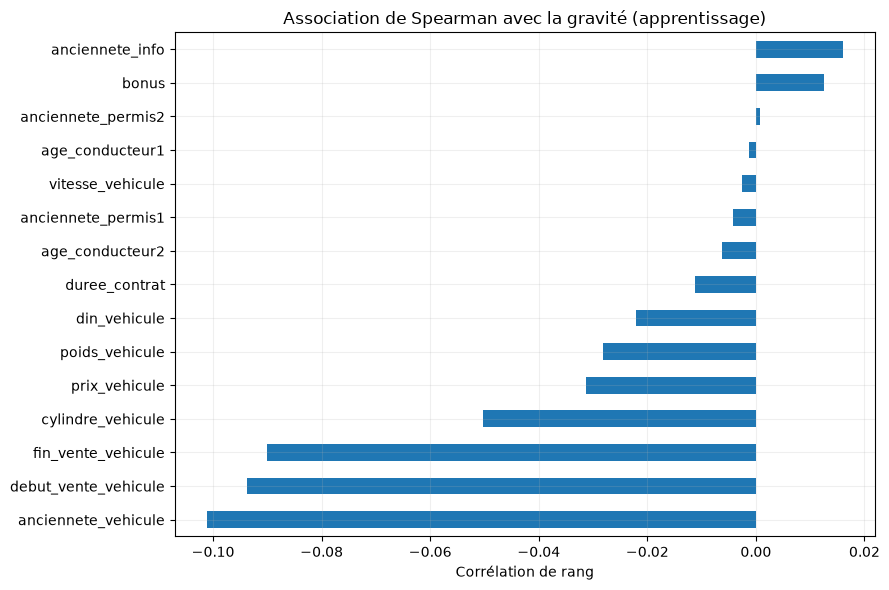

**prix_vehicule, groupes de quantiles**

,count,mean,median
prix_vehicule,,,
"(7088.999, 12850.0]",475,1688.14,1236.00
"(12850.0, 16700.0]",467,1755.37,1236.00
"(16700.0, 20894.4]",469,1862.97,1240.89
"(20894.4, 26550.0]",471,1767.51,1236.00
"(26550.0, 89500.0]",470,1753.48,1236.00


**age_conducteur1, groupes de quantiles**

,count,mean,median
age_conducteur1,,,
"(18.999, 41.0]",485,1814.24,1236.0
"(41.0, 51.0]",502,1906.01,1236.0
"(51.0, 59.0]",464,1703.45,1236.0
"(59.0, 68.0]",446,1716.96,1236.0
"(68.0, 93.0]",455,1668.36,1236.0


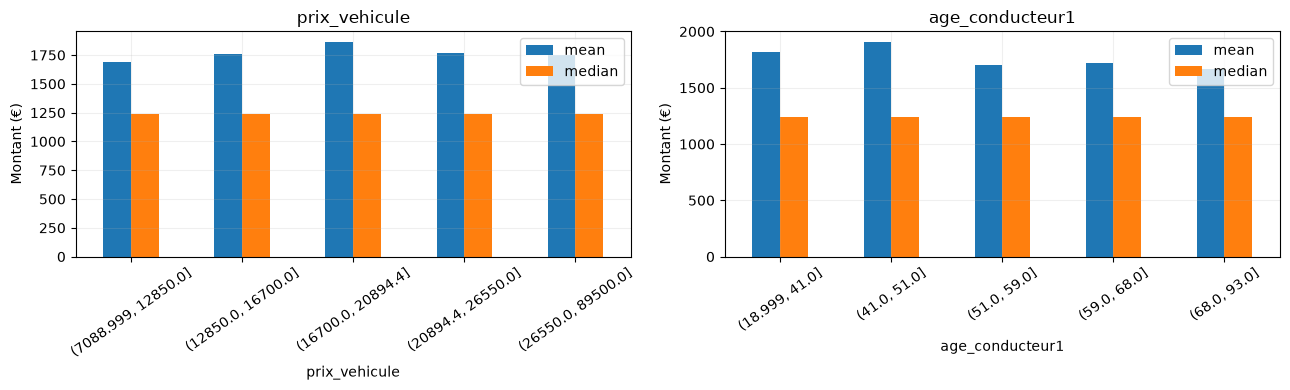

In [7]:
for col in ['type_contrat', 'utilisation', 'essence_vehicule', 'type_vehicule', 'conducteur2']:
    summary = dev.groupby(col, dropna=False)[TARGET].agg(['count','mean','median']).sort_values('mean', ascending=False)
    display(Markdown(f'**{col}**'), summary.round(2))
correlations = dev[num_raw + [TARGET]].corr(method='spearman')[TARGET].drop(TARGET).sort_values()
correlations.plot.barh(figsize=(9,6), title='Association de Spearman avec la gravité (apprentissage)')
plt.xlabel('Corrélation de rang'); plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, col in zip(axes, ['prix_vehicule', 'age_conducteur1']):
    bins = pd.qcut(dev[col], q=5, duplicates='drop')
    summary = dev.groupby(bins, observed=True)[TARGET].agg(['count','mean','median'])
    display(Markdown(f'**{col}, groupes de quantiles**'), summary.round(2))
    summary[['mean','median']].plot.bar(ax=ax, rot=35, title=col)
    ax.set_ylabel('Montant (€)')
plt.tight_layout(); plt.show()

## 7. Préparation réutilisable et catégories inconnues

Nous utilisons uniquement les colonnes disponibles dans les deux fichiers. Les catégories sont encodées en indicatrices ; celles comptant moins de 20 observations **dans le sous-ensemble ajusté** sont regroupées. Cela limite le nombre de paramètres pour les marques, modèles et codes géographiques.

`handle_unknown='infrequent_if_exist'` permet d’appliquer le modèle à une nouvelle modalité : elle rejoint le groupe rare s’il existe, sinon ses indicatrices valent zéro. Les imputations et regroupements sont réappris dans chaque pli de validation croisée. Le test n’intervient dans aucun ajustement.

La standardisation aide la régression Gamma régularisée. Elle est inutile pour les arbres, qui reçoivent les variables numériques imputées à leur échelle initiale.

In [8]:
EXCLUDE = {'index', 'sex_conducteur1', 'sex_conducteur2'}
FEATURES = [c for c in test if c not in EXCLUDE]
CAT = [c for c in FEATURES if not pd.api.types.is_numeric_dtype(train[c])]
NUM = [c for c in FEATURES if c not in CAT]
def prepare_features(df):
    x = df.loc[:, FEATURES].copy()
    for col in ['poids_vehicule', 'cylindre_vehicule']:
        x[col] = x[col].mask(x[col] <= 0)
    for k in [1,2]:
        age, licence = f'age_conducteur{k}', f'anciennete_permis{k}'
        x[licence] = x[licence].mask(x[licence] > x[age])
    for col in CAT:
        x[col] = x[col].astype(object).where(x[col].notna(), np.nan)
    return x

def preprocessing(scale=False):
    numeric_steps = [('imputer', SimpleImputer(strategy='median', add_indicator=True))]
    if scale:
        numeric_steps.append(('scale', StandardScaler()))
    categorical = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='__MANQUANT__')),
        ('encoder', OneHotEncoder(min_frequency=20, handle_unknown='infrequent_if_exist', sparse_output=False))
    ])
    return ColumnTransformer([('num', Pipeline(numeric_steps), NUM), ('cat', categorical, CAT)], remainder='drop')
X_dev, X_val = prepare_features(dev), prepare_features(val)
y_dev, y_val = dev[TARGET], val[TARGET]
groups_dev = dev.id_client
assert TARGET not in FEATURES and CLAIM not in FEATURES
print('Prédicteurs retenus :', len(FEATURES), '| numériques :', len(NUM), '| catégoriels :', len(CAT))
unseen = pd.DataFrame([
    {'variable': c, 'test_inconnu_%': 100*(~test[c].fillna('__MANQUANT__').isin(dev[c].fillna('__MANQUANT__'))).mean()}
    for c in CAT
]).sort_values('test_inconnu_%', ascending=False)
display(unseen.round(2))

Prédicteurs retenus : 25 | numériques : 15 | catégoriels : 10


,variable,test_inconnu_%
4,code_postal,58.04
8,modele_vehicule,7.66
7,marque_vehicule,0.67
0,type_contrat,0.00
1,freq_paiement,0.00
2,paiement,0.00
5,conducteur2,0.00
3,utilisation,0.00
6,essence_vehicule,0.00
9,type_vehicule,0.00


## 7 bis. Analyse dédiée : le code géographique est-il réellement utilisé ?

**Correction importante : `code_postal` n’est pas exclu de `FEATURES`.** Il est transmis au prétraitement catégoriel. Une importance par permutation nulle ne signifie pas que la colonne a été retirée : il faut inspecter ce que l’encodage en fait.

Nous distinguons quatre populations : le train complet, les sinistrés du train, les sinistrés d’apprentissage et le test. Les effectifs utiles pour apprendre la gravité sont ceux des **sinistrés**, pas ceux du portefeuille complet. Un code fréquent parmi tous les contrats peut avoir très peu de sinistres.

Nous ne traitons pas ces codes comme des nombres : la différence entre deux codes n’exprime pas une distance géographique connue. Sans dictionnaire, nous ne supposons pas non plus que les deux premiers caractères constituent un département utilisable.

Cette section explique la représentation initiale. La nouvelle sélection Gamma ci-dessous décide explicitement de la représentation finale ; ne pas assimiler cet audit à une exclusion automatique du département.

,lignes,codes_distincts,effectif_maximum,codes_une_seule_ligne,codes_au_moins_20_lignes,lignes_dans_codes_rares_%
population,,,,,,
Train complet,50000,12790,245,5892,369,67.28
Sinistres train complet,2917,1901,22,1434,1,99.25
Sinistres apprentissage,2352,1621,16,1263,0,100.00
Test prospects,50000,12806,266,5957,357,67.51


,codes_test_inconnus,prospects_code_inconnu_%
reference,,
Train complet,5004,14.964
Sinistres train complet,11254,55.134
Sinistres apprentissage,11459,58.036


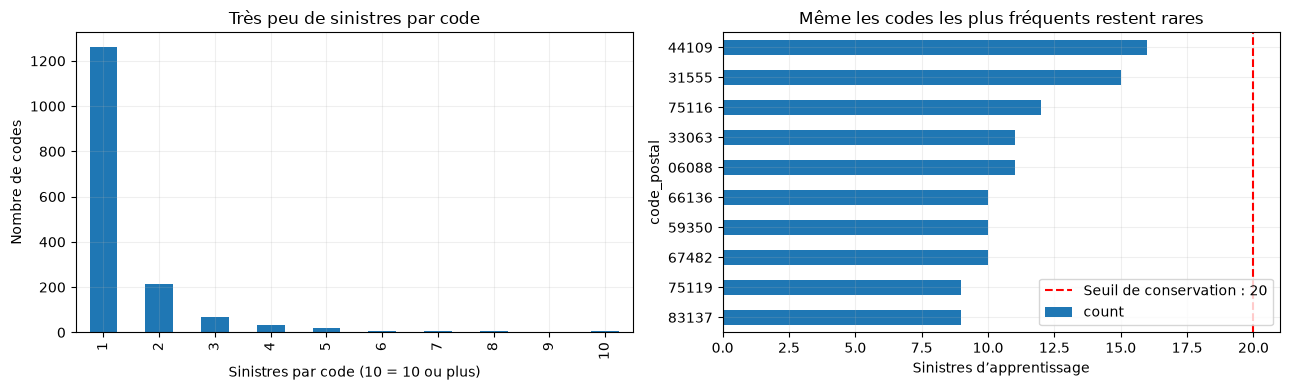

,count,mean,median,std
code_postal,,,,
44109,16,1498.80,1282.75,781.50
31555,15,2038.14,1403.71,1377.31
75116,12,1687.10,1236.00,1235.06
33063,11,2093.05,1236.00,1786.88
06088,11,2595.03,1668.48,2583.28
59350,10,1368.83,1209.63,849.04
66136,10,1323.42,1089.81,553.68
67482,10,1847.71,1229.80,1353.86
75119,9,1146.56,1010.41,452.47


In [9]:
postal_counts = {}
postal_rows = []
for label, frame in [('Train complet', train), ('Sinistres train complet', claims),
                     ('Sinistres apprentissage', dev), ('Test prospects', test)]:
    counts = frame['code_postal'].value_counts(dropna=False)
    postal_counts[label] = counts
    postal_rows.append({'population': label, 'lignes': len(frame), 'codes_distincts': len(counts),
                        'effectif_maximum': counts.max(), 'codes_une_seule_ligne': (counts == 1).sum(),
                        'codes_au_moins_20_lignes': (counts >= 20).sum(),
                        'lignes_dans_codes_rares_%': 100 * counts[counts < 20].sum() / len(frame)})
postal_summary = pd.DataFrame(postal_rows).set_index('population')
display(postal_summary.round(2))
unknown_postal = pd.DataFrame([
    {'reference': label, 'codes_test_inconnus': len(set(test.code_postal)-set(frame.code_postal)),
     'prospects_code_inconnu_%': 100*(~test.code_postal.isin(frame.code_postal)).mean()}
    for label, frame in [('Train complet',train), ('Sinistres train complet',claims), ('Sinistres apprentissage',dev)]
]).set_index('reference')
display(unknown_postal.round(3))
fig, axes = plt.subplots(1, 2, figsize=(13,4))
postal_counts['Sinistres apprentissage'].clip(upper=10).value_counts().sort_index().plot.bar(ax=axes[0])
axes[0].set(xlabel='Sinistres par code (10 = 10 ou plus)', ylabel='Nombre de codes', title='Très peu de sinistres par code')
postal_counts['Sinistres apprentissage'].head(10).sort_values().plot.barh(ax=axes[1])
axes[1].axvline(20, color='red', linestyle='--', label='Seuil de conservation : 20')
axes[1].set(xlabel='Sinistres d’apprentissage', title='Même les codes les plus fréquents restent rares')
axes[1].legend(); plt.tight_layout(); plt.show()
# Exploration limitée à l’apprentissage : ne pas fabriquer un target encoding global.
postal_severity = dev.groupby('code_postal')[TARGET].agg(['count','mean','median','std']).sort_values('count', ascending=False)
display(postal_severity.head(15).round(2))

### Pourquoi l’information géographique disparaît-elle à l’apprentissage ?

L’encodeur utilise `min_frequency=20`. Parmi les 2 352 sinistrés d’apprentissage, il existe 1 621 codes, dont 1 263 n’apparaissent qu’une fois. Le code le plus fréquent n’a que **16 observations**. Tous les codes sont donc réunis dans **une seule catégorie « rare »**.

Pour chaque contrat d’apprentissage et de validation, cette colonne encodée vaut 1. Elle est constante et ne permet pas d’apprendre une différence géographique ; l’intercept du modèle porte déjà une constante. Permuter le code brut ne change donc pas les entrées encodées, d’où l’importance nulle. Les plis de validation croisée sont encore plus petits : aucun ne peut atteindre le seuil de 20 non atteint par leur ensemble parent.

Ce résultat n’établit **pas** que la géographie n’a aucun lien avec les coûts. Il indique que cette représentation fine et ce seuil ne permettent pas de l’estimer avec notre effectif. Les moyennes par code calculées sur un ou deux sinistres sont trop instables pour servir directement à tarifer.

**Dans la configuration initiale utilisant le code détaillé :** sur les 2 917 sinistrés du train, `44109` apparaît 22 fois. Avec exactement la même règle, ce code devient une catégorie propre et les autres restent regroupés. Une régression utilisant cette ancienne représentation pourrait donc utiliser ce contraste après réentraînement complet. Le nouveau modèle final, sélectionné plus bas, n’utilise toutefois ni code détaillé ni département. La structure de la pipeline est identique, mais son vocabulaire ajusté change avec les données. Cette observation historique ne décrit pas le nouveau modèle à trois variables.

**Dans la première version :** la configuration initiale avait été conservée. La nouvelle expérience ci-dessous compare maintenant des sélections explicites, y compris le département. Pour une prochaine version, comparer à l’avance une exclusion explicite, un regroupement géographique documenté, ou un seuil différent. Ne pas choisir ces variantes après examen répété de la validation actuelle. Un encodage par montant moyen demanderait un calcul hors pli pour éviter une fuite de cible.

Documentation du comportement de regroupement : [OneHotEncoder, scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

## 7 bis complément — Le département : la variable géographique demandée

**La question porte sur le département, pas sur le code détaillé à cinq caractères.** Les explications précédentes concernent seulement la colonne brute `code_postal`. Elles ne permettent pas de conclure que le département serait inutile.

La colonne est mal nommée ou au moins ambiguë : des valeurs telles que `2A004` et `2B150` sont compatibles avec des codes de communes INSEE, et ne sont pas des codes postaux numériques usuels. Nous **inférons** ce format à partir des valeurs ; nous ne prétendons pas disposer d’un dictionnaire exhaustif fourni avec les données.

Pour les formats métropolitains observés, le département est le préfixe à deux caractères, en conservant `01`, `2A` et `2B` comme du texte. La fonction ci-dessous traite aussi les codes de communes des départements d’outre-mer 971, 972, 973, 974 et 976 avec un préfixe à trois caractères. Aucun n’apparaît dans les deux CSV actuels. Les formats inconnus ou ambigus, par exemple `20000`, donnent une valeur manquante au lieu d’inventer un département. Les collectivités d’outre-mer ne sont pas assimilées à des départements.

Références : [définition officielle du code commune, Sandre](https://www.sandre.eaufrance.fr/definition/COM/2.0/CdCommune) ; [INSEE : Haute-Corse et exemple de commune Ajaccio 2A004](https://www.insee.fr/fr/metadonnees/geographie/departement/2B-haute-corse).

**Pourquoi le département n’apparaissait-il pas dans le modèle final ?** Parce que la pipeline initiale utilisait le code détaillé directement et ne créait pas cette variable agrégée. C’était un choix de représentation, pas la conséquence d’une comparaison démontrant l’inutilité du département. Nous corrigeons maintenant cette lacune de l’analyse en évaluant explicitement cette représentation.

,departements_distincts,departements_au_moins_20,effectif_maximum,part_lignes_dans_departements_rares_%
population,,,,
Train complet,96,95,2265,0.02
Sinistrés train,95,49,135,18.89
Sinistrés apprentissage,95,43,105,22.92
Test,96,95,2208,0.03


,train_%,test_%,difference_points
67,1.924,2.130,0.206
44,1.980,1.816,-0.164
71,1.054,0.900,-0.154
38,2.032,1.878,-0.154
06,1.842,1.992,0.150
75,2.656,2.802,0.146
13,1.930,2.072,0.142
94,2.240,2.110,-0.130
34,1.680,1.808,0.128
59,4.530,4.416,-0.114


Départements du test inconnus des sinistrés d’apprentissage : ['2B']
Part du test correspondante : 0.026 %


,count,mean,median,std
departement,,,,
59,105,1669.27,1236.00,1484.91
75,83,1606.96,1236.00,940.29
69,70,1902.16,1275.86,1624.02
94,68,1878.45,1386.06,1574.05
78,66,1709.69,1031.69,1531.48
92,61,1854.57,1420.34,1311.37
83,59,1863.23,1236.00,1471.94
33,57,1894.80,1236.66,1232.19
13,56,1765.64,1273.45,1028.00


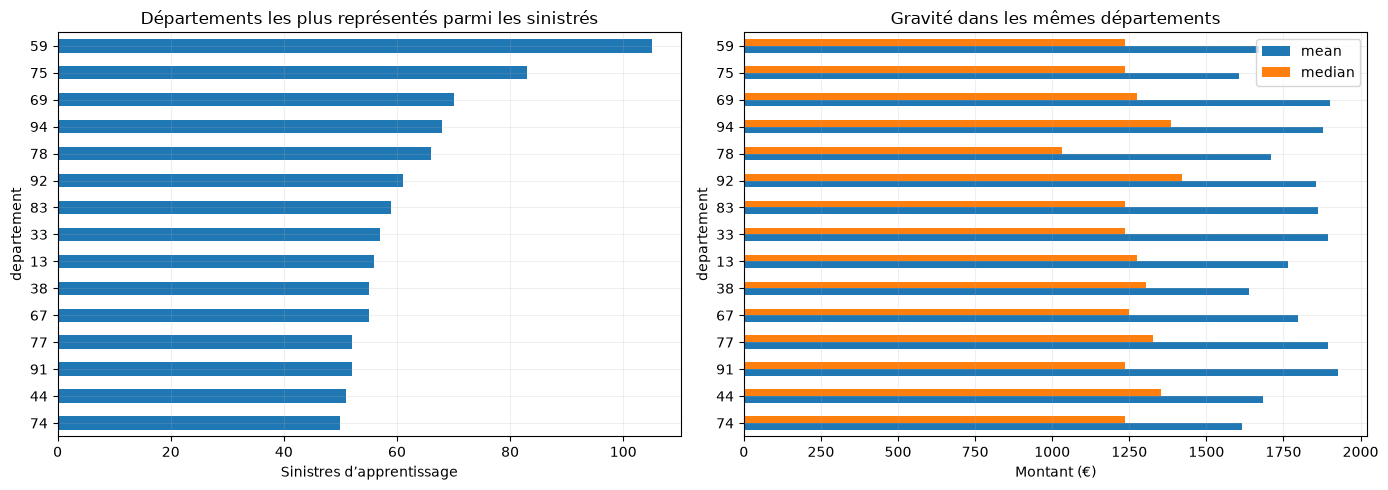

In [10]:
def extraire_departement(codes):
    """Département d’un code communal compatible COG ; formats ambigus -> manquant."""
    s = codes.astype('string').str.strip().str.upper()
    result = pd.Series(np.nan, index=s.index, dtype=object)
    metro = s.str.fullmatch(r'(?:0[1-9]|1[0-9]|2[1-9]|[3-8][0-9]|9[0-5]|2A|2B)[0-9]{3}', na=False)
    dom = s.str.fullmatch(r'97[1-46][0-9]{2}', na=False)
    result.loc[metro] = s.loc[metro].str[:2]
    result.loc[dom] = s.loc[dom].str[:3]
    return result

examples = pd.Series(['01001','2A004','2B150','97101','97411','97601','20000','BAD',None])
expected = ['01','2A','2B','971','974','976']
assert extraire_departement(examples).iloc[:6].tolist() == expected
assert extraire_departement(examples).iloc[6:].isna().all()
dep_train = extraire_departement(train.code_postal)
dep_test = extraire_departement(test.code_postal)
dep_dev = extraire_departement(dev.code_postal)
assert dep_train.notna().all() and dep_test.notna().all()
summary_departments = []
for label, series in [('Train complet',dep_train),('Sinistrés train',dep_train.loc[claims.index]),
                      ('Sinistrés apprentissage',dep_dev),('Test',dep_test)]:
    counts = series.value_counts()
    summary_departments.append({'population':label,'departements_distincts':len(counts),
        'departements_au_moins_20':int((counts>=20).sum()),'effectif_maximum':counts.max(),
        'part_lignes_dans_departements_rares_%':100*counts[counts<20].sum()/len(series)})
display(pd.DataFrame(summary_departments).set_index('population').round(2))
department_shift = pd.DataFrame({'train_%':dep_train.value_counts(normalize=True)*100,
                                  'test_%':dep_test.value_counts(normalize=True)*100}).fillna(0)
department_shift['difference_points'] = department_shift['test_%']-department_shift['train_%']
display(department_shift.reindex(department_shift.difference_points.abs().sort_values(ascending=False).index).head(12).round(3))
print('Départements du test inconnus des sinistrés d’apprentissage :',sorted(set(dep_test)-set(dep_dev)))
print('Part du test correspondante :',f'{100*(~dep_test.isin(dep_dev)).mean():.3f} %')
# Relations à la gravité uniquement sur les sinistrés d’apprentissage.
department_stats = dev.assign(departement=dep_dev).groupby('departement')[TARGET].agg(['count','mean','median','std'])
display(department_stats.sort_values('count',ascending=False).head(20).round(2))
fig,axes=plt.subplots(1,2,figsize=(14,5))
top_departments = department_stats.nlargest(15,'count').sort_values('count')
top_departments['count'].plot.barh(ax=axes[0],title='Départements les plus représentés parmi les sinistrés')
axes[0].set_xlabel('Sinistres d’apprentissage')
top_departments[['mean','median']].plot.barh(ax=axes[1],title='Gravité dans les mêmes départements')
axes[1].set_xlabel('Montant (€)')
plt.tight_layout();plt.show()

### Une représentation plus exploitable, mais pas une preuve de performance

Le portefeuille contient **96 départements**, contre 12 790 codes détaillés. Parmi les 2 352 sinistrés d’apprentissage, **95 départements** sont présents et **43** atteignent le seuil de 20 observations. Ces départements peuvent donc être distingués par le modèle, contrairement aux codes détaillés qui étaient tous regroupés à cette étape.

Les moyennes départementales sont calculées avec leurs effectifs et médianes. Elles ne prouvent pas un effet causal : les départements peuvent différer par les véhicules, les garanties ou les clients assurés. Nous ne calculons pas une corrélation de Pearson entre le numéro de département et le montant : le département est une catégorie sans ordre quantitatif.

Nous comparons maintenant plusieurs sous-ensembles de variables Gamma, dont des variantes avec département, sans géographie et avec code détaillé. Le choix se fait uniquement par validation croisée groupée dans l’apprentissage. La validation réservée, déjà examinée dans les versions précédentes, reste un diagnostic exploratoire et ne sera pas utilisée pour décider.

## 7 ter. Corrélations entre les différents champs

Une corrélation décrit une association, pas une causalité. Nous utilisons uniquement les **sinistrés d’apprentissage**, après les règles fixes de nettoyage, afin de ne pas choisir des variables à partir des montants de validation.

- **Pearson** : association linéaire entre deux variables numériques, sensible aux extrêmes.
- **Spearman** : association monotone entre les rangs, moins dépendante de l’échelle et de la linéarité.
- **V de Cramér corrigé du biais** : association entre deux variables catégorielles, comprise entre 0 et 1 lorsqu’elle est définie. Les catégories ne sont pas converties arbitrairement en nombres.

Le montant est ajouté aux matrices numériques pour étudier ses liens avec les caractéristiques. Les identifiants et les variables de sexe exclues ne sont pas analysés comme prédicteurs. `nombre_sinistres` est constant à 1 dans ce sous-ensemble : sa corrélation n’est pas informative. Le code géographique figure dans les associations catégorielles ; sa forte cardinalité rend l’estimation fragile.

Des variables fortement corrélées peuvent se remplacer et diluer leurs importances individuelles. Ces figures ne déclenchent aucune sélection automatique de variables ni changement du modèle après examen de la validation.

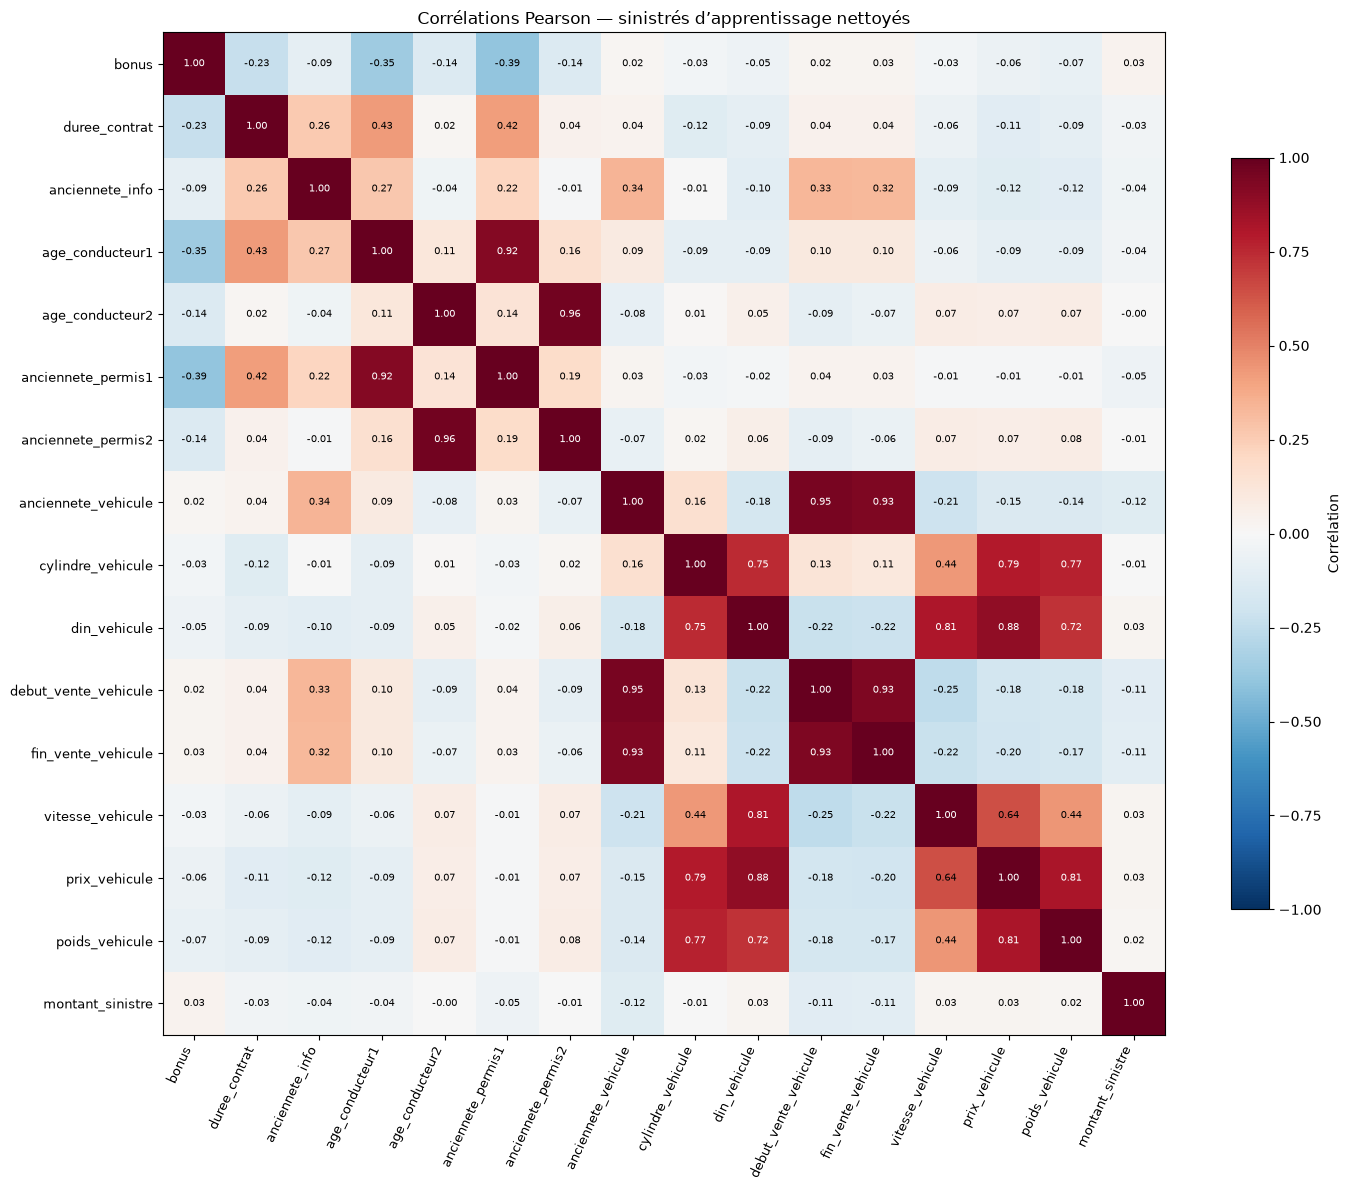

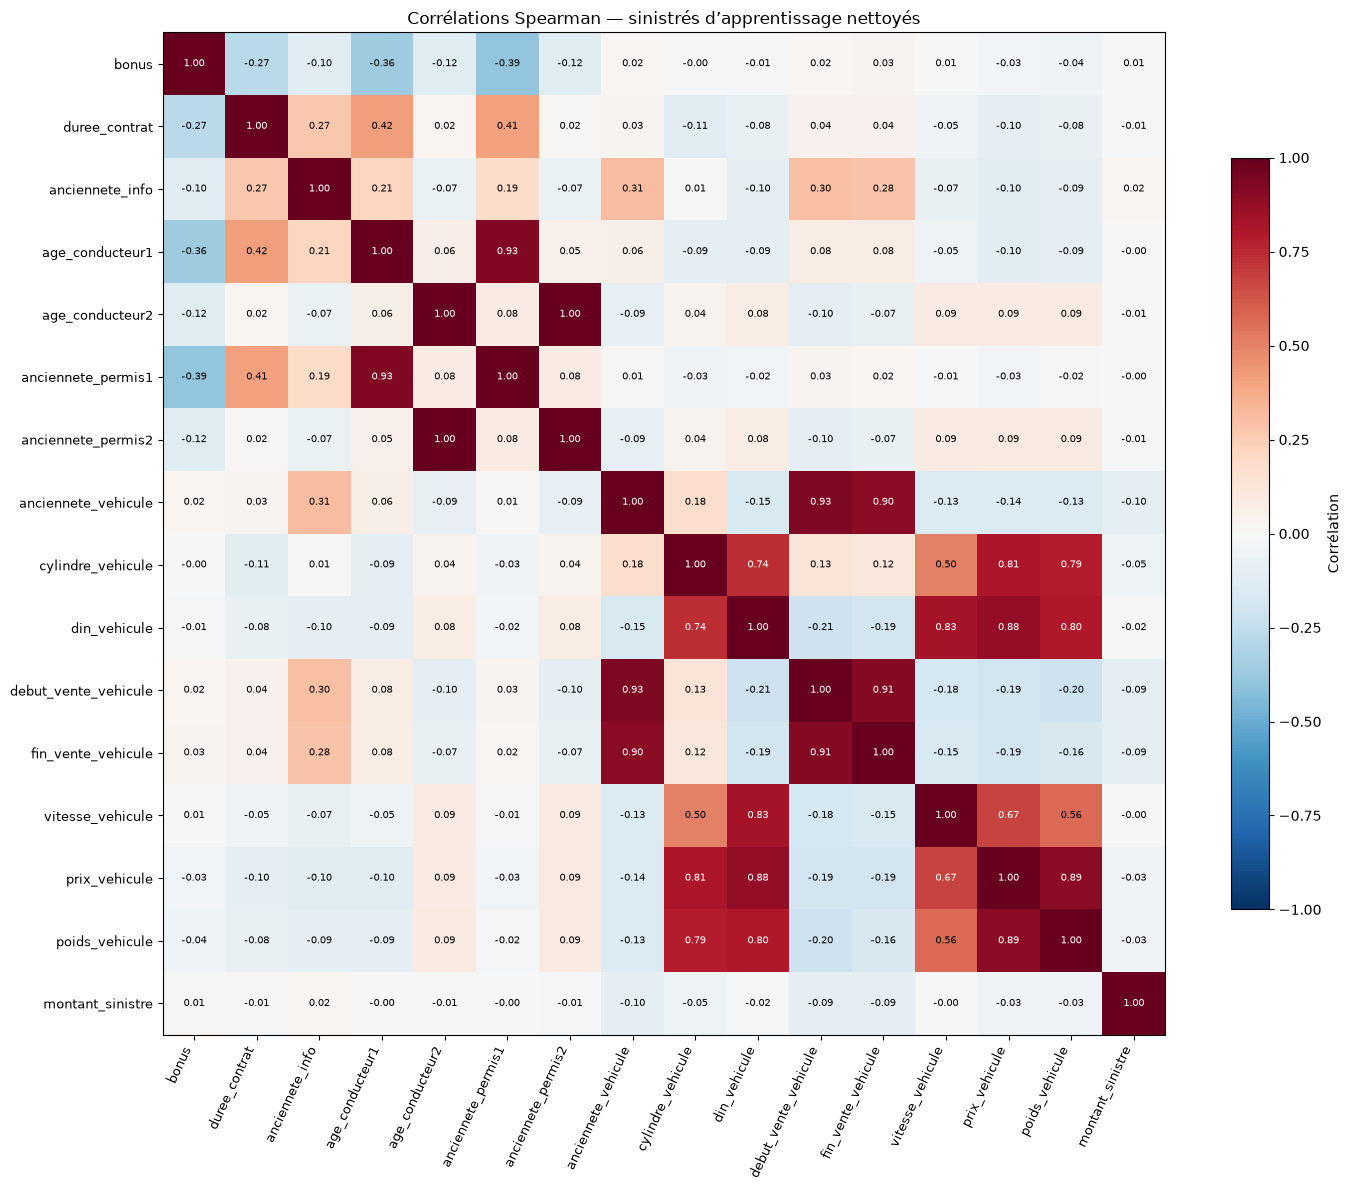

,pearson,spearman
anciennete_vehicule,-0.119,-0.101
debut_vente_vehicule,-0.111,-0.094
fin_vente_vehicule,-0.109,-0.090
cylindre_vehicule,-0.007,-0.050
poids_vehicule,0.022,-0.032
prix_vehicule,0.026,-0.031
din_vehicule,0.029,-0.022
anciennete_info,-0.041,0.016
bonus,0.032,0.012
duree_contrat,-0.034,-0.011


,variable_1,variable_2,spearman
51,age_conducteur2,anciennete_permis2,0.997
79,anciennete_vehicule,debut_vente_vehicule,0.935
40,age_conducteur1,anciennete_permis1,0.926
95,debut_vente_vehicule,fin_vente_vehicule,0.915
80,anciennete_vehicule,fin_vente_vehicule,0.902
104,prix_vehicule,poids_vehicule,0.894
93,din_vehicule,prix_vehicule,0.881
92,din_vehicule,vitesse_vehicule,0.833
88,cylindre_vehicule,prix_vehicule,0.806
94,din_vehicule,poids_vehicule,0.800


In [11]:
# Corrélations numériques : matrice complète et lien avec notre cible.
correlation_data = prepare_features(dev)[NUM].copy()
correlation_data[TARGET] = dev[TARGET]
correlation_results = {}
for method in ['pearson', 'spearman']:
    corr = correlation_data.corr(method=method)
    correlation_results[method] = corr
    fig, ax = plt.subplots(figsize=(15,12))
    im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(corr)), corr.columns, rotation=65, ha='right', fontsize=9)
    ax.set_yticks(range(len(corr)), corr.index, fontsize=9)
    for row in range(len(corr)):
        for col in range(len(corr)):
            value = corr.iloc[row,col]
            if pd.notna(value):
                ax.text(col,row,f'{value:.2f}',ha='center',va='center',fontsize=7,
                        color='white' if abs(value)>.65 else 'black')
    ax.grid(False); ax.set_title(f'Corrélations {method.capitalize()} — sinistrés d’apprentissage nettoyés')
    fig.colorbar(im, ax=ax, shrink=.75, label='Corrélation')
    plt.tight_layout(); plt.show()
relation_target = pd.DataFrame({
    method: matrix[TARGET].drop(TARGET) for method,matrix in correlation_results.items()
})
display(relation_target.reindex(relation_target.spearman.abs().sort_values(ascending=False).index).round(3))
# Montrer les couples les plus corrélés hors cible, sans doublonner A/B et B/A.
strong_pairs = []
num_corr = correlation_results['spearman'].drop(index=TARGET, columns=TARGET)
for i in range(len(num_corr)):
    for j in range(i+1,len(num_corr)):
        strong_pairs.append({'variable_1':num_corr.index[i],'variable_2':num_corr.columns[j],
                             'spearman':num_corr.iloc[i,j]})
strong_pairs = pd.DataFrame(strong_pairs)
display(strong_pairs.reindex(strong_pairs.spearman.abs().sort_values(ascending=False).index).head(12).round(3))

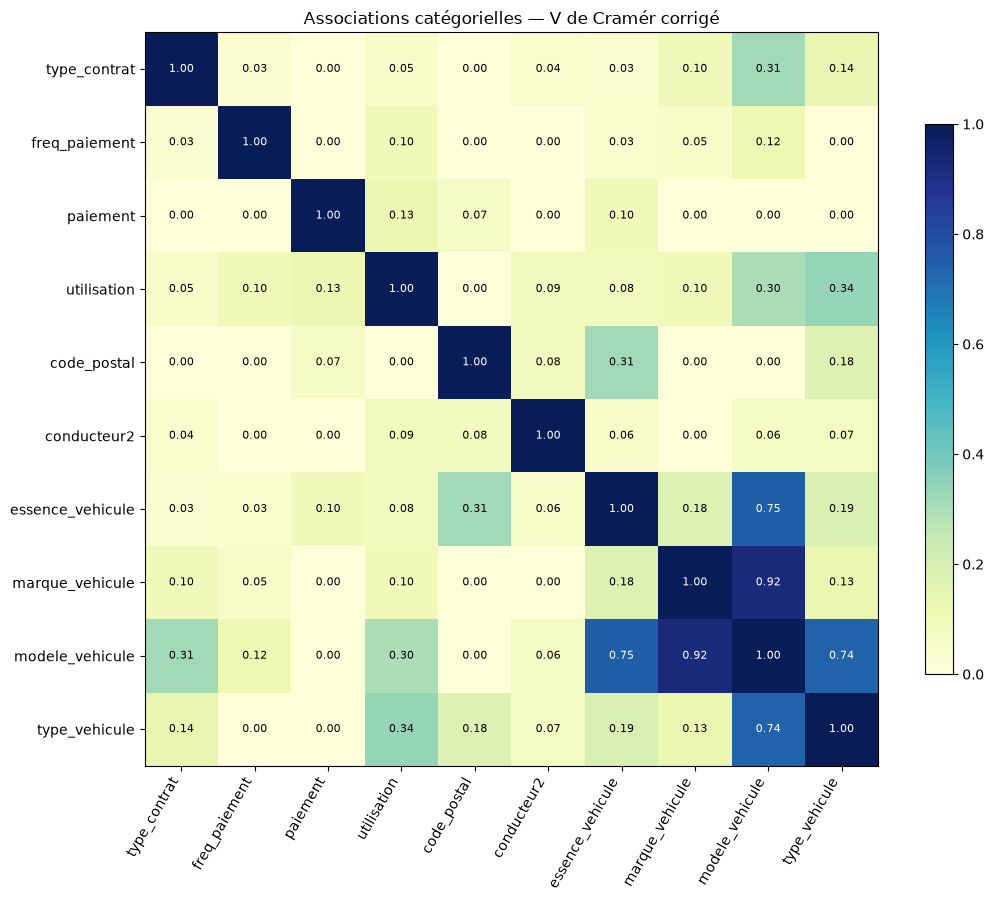

,code_postal
code_postal,1.000
essence_vehicule,0.314
type_vehicule,0.179
conducteur2,0.080
paiement,0.066
type_contrat,0.000
freq_paiement,0.000
utilisation,0.000
marque_vehicule,0.000
modele_vehicule,0.000


Prudence : des tables très creuses (code géographique/modèle) rendent ces estimations peu fiables, même corrigées.


**Associations du département avec les catégories**

,V_Cramer_departement
variable,
code_postal,0.569
type_vehicule,0.138
freq_paiement,0.112
utilisation,0.091
type_contrat,0.063
essence_vehicule,0.039
marque_vehicule,0.022
paiement,0.000
conducteur2,0.000


Le code détaillé est imbriqué dans le département : leur association reflète en partie cette construction.


In [12]:
# Associations catégorielles ; correction du biais lié à la taille des tables.
from scipy.stats import chi2_contingency

def cramers_v_corrected(a,b):
    table = pd.crosstab(a.fillna('__MANQUANT__'), b.fillna('__MANQUANT__'))
    count = table.to_numpy().sum()
    r,k = table.shape
    if count <= 1 or min(r,k) <= 1:
        return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    phi2_corrected = max(0, chi2/count - ((k-1)*(r-1))/(count-1))
    r_corrected = r-(r-1)**2/(count-1)
    k_corrected = k-(k-1)**2/(count-1)
    denominator = min(r_corrected-1,k_corrected-1)
    return np.sqrt(phi2_corrected/denominator) if denominator>0 else np.nan

categorical_associations = pd.DataFrame(np.nan,index=CAT,columns=CAT)
for i,a in enumerate(CAT):
    categorical_associations.loc[a,a] = 1. if dev[a].nunique()>1 else np.nan
    for bb in CAT[i+1:]:
        value = cramers_v_corrected(dev[a],dev[bb])
        categorical_associations.loc[a,bb] = value
        categorical_associations.loc[bb,a] = value
fig,ax = plt.subplots(figsize=(11,9))
im=ax.imshow(categorical_associations.to_numpy(),vmin=0,vmax=1,cmap='YlGnBu')
ax.set_xticks(range(len(CAT)),CAT,rotation=60,ha='right')
ax.set_yticks(range(len(CAT)),CAT)
for i in range(len(CAT)):
    for j in range(len(CAT)):
        value=categorical_associations.iloc[i,j]
        ax.text(j,i,f'{value:.2f}' if pd.notna(value) else 'NA',ha='center',va='center',fontsize=8,
                color='white' if pd.notna(value) and value>.6 else 'black')
ax.grid(False);ax.set_title('Associations catégorielles — V de Cramér corrigé')
fig.colorbar(im,ax=ax,shrink=.75);plt.tight_layout();plt.show()
display(categorical_associations[['code_postal']].sort_values('code_postal',ascending=False).round(3))
print('Prudence : des tables très creuses (code géographique/modèle) rendent ces estimations peu fiables, même corrigées.')
# Association département/autres catégories : pas de corrélation numérique sur ses codes.
department_associations = pd.DataFrame({
    'variable': CAT,
    'V_Cramer_departement': [cramers_v_corrected(dep_dev, dev[col]) for col in CAT]
}).set_index('variable').sort_values('V_Cramer_departement',ascending=False)
display(Markdown('**Associations du département avec les catégories**'), department_associations.round(3))
print('Le code détaillé est imbriqué dans le département : leur association reflète en partie cette construction.')

### Comment interpréter ces matrices ?

Les couleurs proches de +1 ou −1 dans les matrices numériques indiquent des champs redondants ou liés. Une association négative n’est pas mauvaise : elle décrit simplement un sens opposé. Une corrélation faible avec le montant ne prouve pas l’absence d’un effet non linéaire ou d’une interaction.

Pour les catégories, 0 signifie une faible association mesurée et 1 une forte association ; il n’y a pas de signe positif/négatif. La correction réduit le biais des grandes tables sans résoudre le manque d’observations par code. Ces associations portent sur les **codes bruts** : elles ne changent pas le fait que notre encodage regroupe tous les codes lors de l’apprentissage local.

Enfin, ces résultats concernent la gravité parmi les sinistrés. Ils ne décrivent pas nécessairement les associations dans tout le portefeuille et ne répondent pas à la question de la probabilité d’accident.

**Lecture de cette exécution :** l’âge du conducteur principal et son ancienneté de permis ont une corrélation de Spearman proche de 0,93. Le prix et la puissance du véhicule sont également fortement liés (environ 0,88), ainsi que le prix et le poids (environ 0,89). Les corrélations monotones directes avec le montant restent faibles, autour de −0,10 au maximum en valeur absolue dans ces champs. Cela aide à comprendre le faible gain par rapport à la moyenne, sans exclure l’existence d’autres interactions.

La corrélation presque parfaite entre âge et ancienneté de permis du second conducteur demande de la prudence : leurs nombreux zéros communs lorsque ce conducteur est absent contribuent à l’association. Il faudrait analyser séparément les contrats avec second conducteur avant de l’interpréter comme une relation parmi ces conducteurs. Les matrices ignorent les valeurs manquantes paire par paire ; elles n’utilisent pas l’imputation du modèle.

## 8. Nouvelle comparaison : uniquement des régressions Gamma

**Nous gardons la même famille : Gamma à lien logarithmique, avec régularisation L2.** Nous cherchons maintenant quelles caractéristiques conserver et quelle intensité de régularisation utiliser. Aucun modèle de fréquence n’est construit.

Nous définissons à l’avance dix ensembles de variables, en nous appuyant sur les groupes métier, la rareté des catégories et les redondances observées. La grille commune est `alpha ∈ {0.01, 0.1, 1, 10, 100}`. Le seuil de regroupement catégoriel reste 20 pour éviter de multiplier les choix sur peu de sinistres.

Les variantes comparent : code détaillé / département / absence de géographie ; retrait des marques et modèles fins ; retrait d’un groupe de caractéristiques redondantes ; versions métier compactes ; contrats seuls ; modèles très simples. Une amélioration ne sera pas attribuée à une seule variable si plusieurs ont été retirées ensemble.

**Critère de choix : plus petit RMSE moyen sur cinq plis groupés par client de l’apprentissage local.** Le MAE, le biais et la stabilité complètent l’analyse sans changer ce critère. Un petit écart ne constitue pas à lui seul un gain établi.

**Limite de l’évaluation :** les données de validation ont déjà été consultées, et les familles de variables sont motivées par notre exploration précédente. Une validation croisée imbriquée contrôle les ajustements effectués à l’intérieur de ses plis, mais n’efface pas les décisions humaines prises après exploration du jeu de développement. Ses résultats sont une estimation interne, pas une garantie indépendante de performance future.

In [13]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import cross_val_predict
import json, hashlib, cloudpickle, subprocess, time

RAW_FEATURES = [c for c in test if c not in {'index','sex_conducteur1','sex_conducteur2'}]
NO_GEO = [c for c in RAW_FEATURES if c != 'code_postal']
WITH_DEPT = NO_GEO + ['departement']
FEATURE_SETS = {
    'Toutes_code_detaille': RAW_FEATURES,
    'Toutes_departement': WITH_DEPT,
    'Toutes_sans_geographie': NO_GEO,
    'Sans_categories_fines': [c for c in WITH_DEPT if c not in {'marque_vehicule','modele_vehicule'}],
    'Moins_redondantes': [c for c in WITH_DEPT if c not in {
        'age_conducteur1','anciennete_permis2','cylindre_vehicule','din_vehicule',
        'poids_vehicule','vitesse_vehicule','debut_vente_vehicule','fin_vente_vehicule',
        'marque_vehicule','modele_vehicule'}],
    'Metier_compact': ['bonus','type_contrat','duree_contrat','utilisation','age_conducteur1',
        'anciennete_permis1','anciennete_vehicule','prix_vehicule','conducteur2','departement'],
    'Metier_compact_sans_geo': ['bonus','type_contrat','duree_contrat','utilisation','age_conducteur1',
        'anciennete_permis1','anciennete_vehicule','prix_vehicule','conducteur2'],
    'Contrat_seul': ['bonus','type_contrat','duree_contrat','anciennete_info','freq_paiement','paiement','utilisation'],
    'Minimal_contrat_vehicule': ['type_contrat','anciennete_vehicule','utilisation'],
    'Minimal_contrat_permis': ['type_contrat','anciennete_permis1','utilisation'],
}
ALPHAS = [.01,.1,1.,10.,100.]
SCHEMA = train.iloc[:0].copy()
SCHEMA['departement'] = pd.Series(dtype=object)
FORBIDDEN = {'index','id_client','id_vehicule','id_contrat',CLAIM,TARGET,'sex_conducteur1','sex_conducteur2'}
for name,features in FEATURE_SETS.items():
    assert not FORBIDDEN.intersection(features)
    assert len(features) == len(set(features))

def required_raw_columns(features):
    required = set(features)-{'departement'}
    if 'departement' in features: required.add('code_postal')
    # Ces âges servent à vérifier les anciennetés, même s’ils ne sont pas prédicteurs.
    for k in [1,2]:
        if f'anciennete_permis{k}' in required: required.add(f'age_conducteur{k}')
    return sorted(required)

def clean_gamma_inputs(frame, required_columns=None):
    if required_columns:
        missing = sorted(set(required_columns)-set(frame.columns))
        if missing: raise ValueError(f'Colonnes nécessaires absentes : {missing}')
    x=frame.copy()
    if 'code_postal' in x:
        x['departement']=extraire_departement(x.code_postal)
    for col in ['poids_vehicule','cylindre_vehicule']:
        if col in x: x[col]=x[col].mask(x[col]<=0)
    for k in [1,2]:
        age,lic=f'age_conducteur{k}',f'anciennete_permis{k}'
        if lic in x and age in x: x[lic]=x[lic].mask(x[lic]>x[age])
    for col in x.select_dtypes(include=['object','string']).columns:
        x[col]=x[col].astype(object).where(x[col].notna(),np.nan)
    return x

def make_gamma_preprocessor(features):
    numeric=[c for c in features if pd.api.types.is_numeric_dtype(SCHEMA[c])]
    categorical=[c for c in features if c not in numeric]
    return ColumnTransformer([
        ('num',Pipeline([('imputer',SimpleImputer(strategy='median',add_indicator=True)),
                         ('scale',StandardScaler())]),numeric),
        ('cat',Pipeline([('imputer',SimpleImputer(strategy='constant',fill_value='__MANQUANT__')),
                         ('encoder',OneHotEncoder(min_frequency=20,handle_unknown='infrequent_if_exist',sparse_output=False))]),categorical)
    ],remainder='drop')

def label_preprocessor(prep):
    used=sorted([col for _,_,cols in prep.transformers for col in cols])
    return next(name for name,cols in FEATURE_SETS.items() if sorted(cols)==used)

# Le nettoyage est dans la pipeline : predict recevra directement les colonnes brutes.
GAMMA_TEMPLATE = Pipeline([
    ('clean',FunctionTransformer(clean_gamma_inputs,validate=False)),
    ('prep',make_gamma_preprocessor(RAW_FEATURES)),
    ('model',GammaRegressor(max_iter=3000,tol=1e-5,solver='lbfgs'))
])
PARAM_GRID=[{'prep':[make_gamma_preprocessor(features)],'model__alpha':ALPHAS}
            for features in FEATURE_SETS.values()]
CV_SELECTION=list(GroupKFold(n_splits=5,shuffle=True,random_state=2026).split(dev,dev[TARGET],groups=dev.id_client))
for left,right in CV_SELECTION:
    assert set(dev.iloc[left].id_client).isdisjoint(set(dev.iloc[right].id_client))

def gamma_search(cv_splits):
    return GridSearchCV(GAMMA_TEMPLATE,PARAM_GRID,cv=cv_splits,
        scoring={'RMSE':'neg_root_mean_squared_error','MAE':'neg_mean_absolute_error'},
        refit='RMSE',return_train_score=True,error_score='raise',n_jobs=1)

feature_design=pd.DataFrame([{'variante':name,'nombre_variables':len(cols),'variables':', '.join(cols)}
                             for name,cols in FEATURE_SETS.items()]).set_index('variante')
display(feature_design)
print('50 configurations Gamma ; cinq plis groupés, prétraitements réappris dans chaque pli.')

,nombre_variables,variables
variante,,
Toutes_code_detaille,25,"bonus, type_contrat, duree_contrat, anciennete..."
Toutes_departement,25,"bonus, type_contrat, duree_contrat, anciennete..."
Toutes_sans_geographie,24,"bonus, type_contrat, duree_contrat, anciennete..."
Sans_categories_fines,23,"bonus, type_contrat, duree_contrat, anciennete..."
Moins_redondantes,15,"bonus, type_contrat, duree_contrat, anciennete..."
Metier_compact,10,"bonus, type_contrat, duree_contrat, utilisatio..."
Metier_compact_sans_geo,9,"bonus, type_contrat, duree_contrat, utilisatio..."
Contrat_seul,7,"bonus, type_contrat, duree_contrat, anciennete..."
Minimal_contrat_vehicule,3,"type_contrat, anciennete_vehicule, utilisation"


50 configurations Gamma ; cinq plis groupés, prétraitements réappris dans chaque pli.


## 9. Comparaison des variables et de la régularisation

Le jeu de validation réservé ne participe pas à cette recherche. Chaque configuration apprend ses coefficients, imputations, standardisation et catégories rares dans chaque pli d’apprentissage. Le RMSE est mesuré sur les sinistrés du pli exclu.

Nous comparons la moyenne des RMSE par pli et affichons également leur écart-type. Ce dernier décrit une variabilité interne ; ce n’est pas un intervalle de confiance. La meilleure ligne parmi 50 bénéficie d’un effet de sélection : son score est généralement optimiste comme estimation de la procédure entière.

Les ensembles et leurs paramètres sont comparés sur exactement les mêmes plis. Une moyenne constante réapprise dans chaque pli reste la référence métier.

,variante,n_variables,alpha,RMSE_CV,ecart_type_CV,MAE_CV,RMSE_apprentissage_CV
0,Minimal_contrat_vehicule,3,0.1,1491.183,153.123,931.604,1494.959
2,Metier_compact_sans_geo,9,0.1,1493.625,153.736,933.601,1491.457
3,Metier_compact,10,0.1,1493.828,153.703,932.388,1487.065
4,Sans_categories_fines,23,1.0,1494.013,151.175,936.175,1493.515
5,Toutes_departement,25,1.0,1494.041,151.130,935.980,1492.805
7,Toutes_sans_geographie,24,1.0,1494.286,151.119,936.432,1493.584
8,Toutes_code_detaille,25,1.0,1494.287,151.118,936.434,1493.584
11,Minimal_contrat_permis,3,0.1,1494.430,153.718,937.785,1497.430
12,Moins_redondantes,15,0.1,1494.496,153.794,932.891,1485.328
20,Contrat_seul,7,0.1,1495.363,154.573,937.733,1494.370


Baseline moyenne, RMSE CV : 1503.7516522997107
SÉLECTION : Minimal_contrat_vehicule | alpha = 0.1
Temps de recherche (s) : 37.7


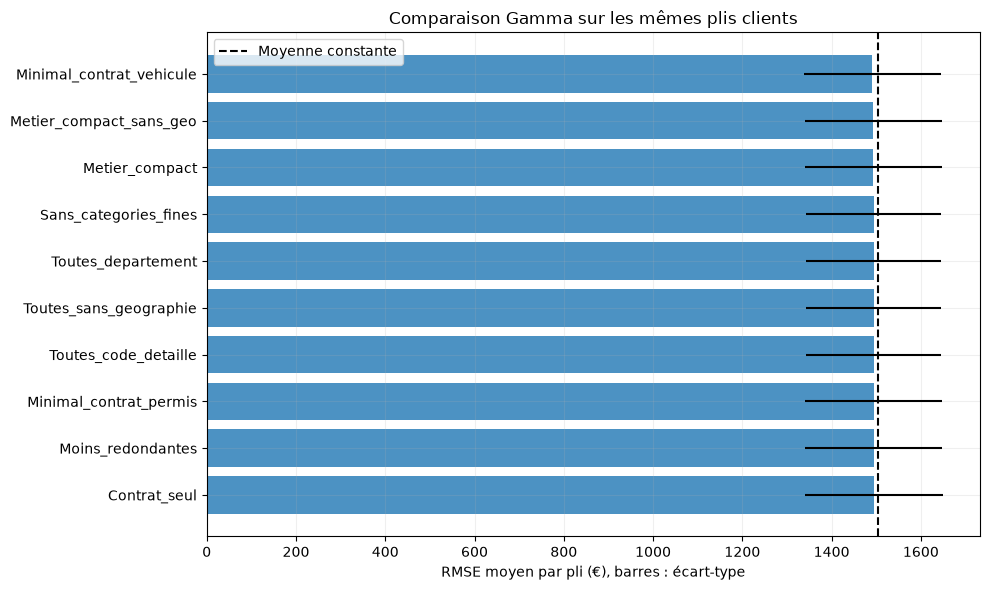

,variante,n_variables,alpha,RMSE_CV,ecart_vs_toutes_departement
0,Minimal_contrat_vehicule,3,0.1,1491.1834,-2.8580
2,Metier_compact_sans_geo,9,0.1,1493.6246,-0.4168
3,Metier_compact,10,0.1,1493.8285,-0.2130
4,Sans_categories_fines,23,1.0,1494.0128,-0.0286
5,Toutes_departement,25,1.0,1494.0415,0.0000
7,Toutes_sans_geographie,24,1.0,1494.2861,0.2446
8,Toutes_code_detaille,25,1.0,1494.2867,0.2453
11,Minimal_contrat_permis,3,0.1,1494.4296,0.3882
12,Moins_redondantes,15,0.1,1494.4964,0.4549
20,Contrat_seul,7,0.1,1495.3632,1.3218


In [14]:
started=time.perf_counter()
selection_gamma=gamma_search(CV_SELECTION)
selection_gamma.fit(dev,dev[TARGET])
results=selection_gamma.cv_results_
selection_rows=[]
for i,parameters in enumerate(results['params']):
    label=label_preprocessor(parameters['prep'])
    selection_rows.append({'variante':label,'n_variables':len(FEATURE_SETS[label]),
        'alpha':parameters['model__alpha'],'RMSE_CV':-results['mean_test_RMSE'][i],
        'ecart_type_CV':results['std_test_RMSE'][i], 'MAE_CV':-results['mean_test_MAE'][i],
        'RMSE_apprentissage_CV':-results['mean_train_RMSE'][i], 'index_resultat':i})
selection_scores=pd.DataFrame(selection_rows).sort_values(['RMSE_CV','n_variables','alpha']).reset_index(drop=True)
best_per_set=selection_scores.groupby('variante',sort=False).head(1).copy()
WINNER_SET=label_preprocessor(selection_gamma.best_params_['prep'])
WINNER_ALPHA=float(selection_gamma.best_params_['model__alpha'])
SELECTED_FEATURES=list(FEATURE_SETS[WINNER_SET])
selected_gamma_dev=selection_gamma.best_estimator_
# Renforcer le contrat d’entrée après sélection ; n’affecte pas l’apprentissage.
selected_gamma_dev.named_steps['clean'].set_params(kw_args={'required_columns':required_raw_columns(SELECTED_FEATURES)})
baseline_folds=[]
for left,right in CV_SELECTION:
    estimate=np.full(len(right),dev.iloc[left][TARGET].mean())
    baseline_folds.append(root_mean_squared_error(dev.iloc[right][TARGET],estimate))
BASELINE_CV=float(np.mean(baseline_folds))
display(best_per_set.drop(columns='index_resultat').round(3))
print('Baseline moyenne, RMSE CV :',BASELINE_CV)
print('SÉLECTION :',WINNER_SET,'| alpha =',WINNER_ALPHA)
print('Temps de recherche (s) :',round(time.perf_counter()-started,1))
fig,ax=plt.subplots(figsize=(10,6))
ordered=best_per_set.sort_values('RMSE_CV',ascending=False)
ax.barh(ordered.variante,ordered.RMSE_CV,xerr=ordered.ecart_type_CV,alpha=.8)
ax.axvline(BASELINE_CV,color='black',linestyle='--',label='Moyenne constante')
ax.set(xlabel='RMSE moyen par pli (€), barres : écart-type',title='Comparaison Gamma sur les mêmes plis clients')
ax.legend();plt.tight_layout();plt.show()
# Détail du gain/perte de retrait par groupes, même grille d’alpha et mêmes plis.
reference_score=float(best_per_set.loc[best_per_set.variante=='Toutes_departement','RMSE_CV'].iloc[0])
comparison_groups=best_per_set[['variante','n_variables','alpha','RMSE_CV']].copy()
comparison_groups['ecart_vs_toutes_departement']=comparison_groups.RMSE_CV-reference_score
display(comparison_groups.round(4))

## 10. Validation croisée imbriquée : évaluer la procédure de sélection

Une boucle externe de **quatre plis groupés** réserve à chaque fois des clients. Dans les trois plis internes, nous recommençons toute la sélection des 50 configurations, exclusivement dans l’apprentissage externe. Le gagnant interne est alors évalué sur le pli externe qu’il n’a jamais vu.

Cette étape évalue la procédure « choisir les variables et alpha, puis apprendre Gamma », et pas seulement la configuration gagnante sur tout le développement. Les gagnants peuvent varier : cette variation renseigne sur la fragilité de la sélection. Nous enregistrons les prédictions hors pli, le RMSE global, les RMSE par pli et une comparaison à la moyenne constante apprise dans les mêmes plis.

Les observations de validation réservée ne sont utilisées ni ici ni pour sélectionner la configuration finale. La validation imbriquée reste interne aux données déjà explorées ; elle ne transforme pas notre travail itératif en test externe indépendant.

In [15]:
outer_cv=GroupKFold(n_splits=4,shuffle=True,random_state=2701)
nested_predictions=np.full(len(dev),np.nan)
nested_baseline=np.full(len(dev),np.nan)
nested_rows=[]
for fold,(outer_train,outer_test) in enumerate(outer_cv.split(dev,dev[TARGET],groups=dev.id_client),start=1):
    fold_train=dev.iloc[outer_train]
    fold_test=dev.iloc[outer_test]
    assert set(fold_train.id_client).isdisjoint(set(fold_test.id_client))
    inner_cv=list(GroupKFold(n_splits=3,shuffle=True,random_state=3000+fold).split(
        fold_train,fold_train[TARGET],groups=fold_train.id_client))
    search=gamma_search(inner_cv)
    search.fit(fold_train,fold_train[TARGET])
    pred=search.predict(fold_test)
    base=np.full(len(fold_test),fold_train[TARGET].mean())
    nested_predictions[outer_test]=pred
    nested_baseline[outer_test]=base
    nested_rows.append({'pli_externe':fold,'variante':label_preprocessor(search.best_params_['prep']),
        'alpha':float(search.best_params_['model__alpha']),'sinistres_test':len(fold_test),
        'RMSE_Gamma':root_mean_squared_error(fold_test[TARGET],pred),
        'RMSE_moyenne':root_mean_squared_error(fold_test[TARGET],base)})
    print('Pli externe',fold,'terminé :',nested_rows[-1]['variante'],flush=True)
assert np.isfinite(nested_predictions).all() and (nested_predictions>0).all()
nested_results=pd.DataFrame(nested_rows).set_index('pli_externe')
display(nested_results.round(3))
NESTED_RMSE=root_mean_squared_error(dev[TARGET],nested_predictions)
NESTED_BASELINE_RMSE=root_mean_squared_error(dev[TARGET],nested_baseline)
print('RMSE global hors pli, procédure Gamma :',NESTED_RMSE)
print('RMSE global hors pli, moyenne constante :',NESTED_BASELINE_RMSE)
print('Gain relatif de la procédure :',100*(1-NESTED_RMSE/NESTED_BASELINE_RMSE),'%')
print('Fréquence des gagnants externes :')
display(nested_results.variante.value_counts().rename('plis'))

Pli externe 1 terminé : Minimal_contrat_vehicule


Pli externe 2 terminé : Metier_compact_sans_geo


Pli externe 3 terminé : Minimal_contrat_vehicule


Pli externe 4 terminé : Minimal_contrat_vehicule


,variante,alpha,sinistres_test,RMSE_Gamma,RMSE_moyenne
pli_externe,,,,,
1,Minimal_contrat_vehicule,0.10,589,1603.458,1615.109
2,Metier_compact_sans_geo,0.01,588,1254.370,1264.734
3,Minimal_contrat_vehicule,0.10,589,1252.813,1257.210
4,Minimal_contrat_vehicule,0.10,586,1810.423,1827.866


RMSE global hors pli, procédure Gamma : 1498.9651489218277
RMSE global hors pli, moyenne constante : 1510.427237375134
Gain relatif de la procédure : 0.7588639935562469 %
Fréquence des gagnants externes :


variante
Minimal_contrat_vehicule    3
Metier_compact_sans_geo     1
Name: plis, dtype: int64

## 11. Quelles variables garde-t-on réellement ?

Le tableau distingue une **variable utilisée comme prédicteur** d’une **colonne nécessaire pour préparer une autre variable**. Par exemple, le département nécessite le code détaillé ; une ancienneté de permis peut nécessiter l’âge pour vérifier sa cohérence. Cela n’ajoute pas automatiquement ces colonnes aux prédicteurs.

Le sexe, les identifiants et les cibles sont exclus a priori. Pour les autres variables, « exclue » signifie simplement que l’ensemble gagnant ne la contient pas, pas qu’une expérience isolée a démontré son inutilité. La comparaison porte sur des groupes prédéfinis ; le meilleur ensemble trouvé n’est pas nécessairement le meilleur parmi les millions de sous-ensembles possibles.

Dans le modèle retenu de cette exécution, le **département est réellement exclu** : il a été testé dans plusieurs variantes, mais l’ensemble sans géographie à trois variables obtient un RMSE CV légèrement plus faible. Cette justification est différente de celle du code détaillé regroupé : le département disposait bien d’observations suffisantes pour plusieurs modalités. L’écart reste trop petit pour conclure à une absence de signal géographique dans la population.

In [16]:
required_inputs=required_raw_columns(SELECTED_FEATURES)
all_candidates=RAW_FEATURES+['departement']
variable_decisions=pd.DataFrame({
    'variable':all_candidates,
    'predicteur_retenu':[c in SELECTED_FEATURES for c in all_candidates],
    'necessaire_entree_brute':[c in required_inputs for c in all_candidates]})
variable_decisions['decision']=np.where(variable_decisions.predicteur_retenu,'Conservée',
    np.where(variable_decisions.necessaire_entree_brute,'Préparation seulement','Exclue du modèle sélectionné'))
display(variable_decisions)
print('Configuration retenue :',WINNER_SET,'; alpha =',WINNER_ALPHA)
print('Prédicteurs :',SELECTED_FEATURES)
print('Colonnes brutes nécessaires :',required_inputs)
# Les coefficients agissent sur le log de la moyenne, pas directement en euros.
encoded_names=selected_gamma_dev.named_steps['prep'].get_feature_names_out()
coefficient_table=pd.DataFrame({'variable_encodee':encoded_names,
    'coefficient':selected_gamma_dev.named_steps['model'].coef_})
coefficient_table['facteur_une_unite']=np.exp(coefficient_table.coefficient)
display(coefficient_table.reindex(coefficient_table.coefficient.abs().sort_values(ascending=False).index).head(20).round(5))
print('Colonnes transformées :',len(encoded_names),'| intercept :',selected_gamma_dev.named_steps['model'].intercept_)

,variable,predicteur_retenu,necessaire_entree_brute,decision
0,bonus,False,False,Exclue du modèle sélectionné
1,type_contrat,True,True,Conservée
2,duree_contrat,False,False,Exclue du modèle sélectionné
3,anciennete_info,False,False,Exclue du modèle sélectionné
4,freq_paiement,False,False,Exclue du modèle sélectionné
5,paiement,False,False,Exclue du modèle sélectionné
6,utilisation,True,True,Conservée
7,code_postal,False,False,Exclue du modèle sélectionné
8,conducteur2,False,False,Exclue du modèle sélectionné
9,age_conducteur1,False,False,Exclue du modèle sélectionné


Configuration retenue : Minimal_contrat_vehicule ; alpha = 0.1
Prédicteurs : ['type_contrat', 'anciennete_vehicule', 'utilisation']
Colonnes brutes nécessaires : ['anciennete_vehicule', 'type_contrat', 'utilisation']


,variable_encodee,coefficient,facteur_une_unite
0,num__anciennete_vehicule,-0.07974,0.92335
3,cat__type_contrat_Median2,-0.07200,0.93053
1,cat__type_contrat_Maxi,0.05884,1.06060
6,cat__utilisation_Retired,-0.03977,0.96101
5,cat__utilisation_Professional,0.03115,1.03164
7,cat__utilisation_WorkPrivate,0.01475,1.01486
2,cat__type_contrat_Median1,0.01363,1.01372
8,cat__utilisation_infrequent_sklearn,-0.00615,0.99387
4,cat__type_contrat_Mini,-0.00049,0.99951


Colonnes transformées : 9 | intercept : 7.424983506691345


## 12. Diagnostic sur la validation historique, après sélection

Nous comparons le Gamma sélectionné à la moyenne constante et à la Gamma initiale (`alpha=1`, toutes les variables brutes hors sexe et identifiants) sur les **mêmes 565 sinistrés**. Nous ne changeons pas le gagnant si l’ancienne Gamma obtient un meilleur score sur cette validation.

Cette validation a déjà été vue : ces scores servent à expliquer le résultat de l’exercice, **pas à annoncer une performance indépendante**. Le RMSE de gravité ne constitue pas le score Kaggle sur les primes. Une Gamma peut être le meilleur candidat Gamma testé et néanmoins ne pas battre une moyenne constante ; nous le signalerons si c’est le cas.

,RMSE,MAE,biais,ratio_sommes
modele,,,,
Gamma_selectionne,1245.7982,920.9559,-24.7331,0.9863
Gamma_initial,1248.7803,924.4799,-31.1818,0.9827
Moyenne,1253.6061,935.3519,-33.7790,0.9812


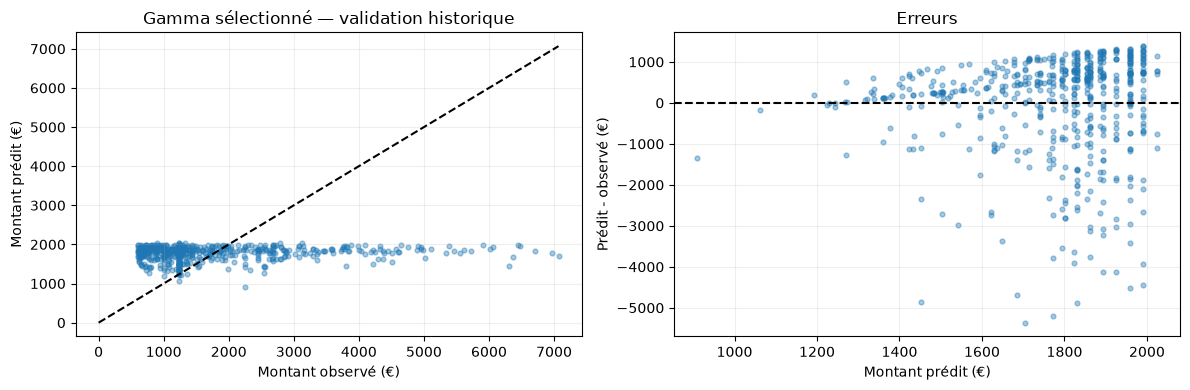

,n,RMSE,MAE,biais,ratio_sommes
segment,,,,,
Autres,494,761.729,664.793,360.239,1.256
Couteux >=P90 apprentissage,71,2883.302,2703.274,-2703.274,0.404


In [17]:
def gravity_metrics(observed,predicted):
    observed=np.asarray(observed,dtype=float);predicted=np.asarray(predicted,dtype=float)
    if not np.isfinite(predicted).all() or (predicted<=0).any():
        raise ValueError('Les montants doivent être finis et strictement positifs.')
    return {'RMSE':root_mean_squared_error(observed,predicted),
            'MAE':mean_absolute_error(observed,predicted),
            'biais':float(np.mean(predicted-observed)),
            'ratio_sommes':float(predicted.sum()/observed.sum())}

pred_gamma_selected=selected_gamma_dev.predict(val)
initial_gamma=Pipeline([
    ('clean',FunctionTransformer(clean_gamma_inputs,validate=False)),
    ('prep',make_gamma_preprocessor(RAW_FEATURES)),
    ('model',GammaRegressor(alpha=1.,max_iter=3000,tol=1e-5,solver='lbfgs'))])
initial_gamma.fit(dev,dev[TARGET])
pred_gamma_initial=initial_gamma.predict(val)
pred_mean=np.full(len(val),dev[TARGET].mean())
validation_predictions={'Gamma_selectionne':pred_gamma_selected,'Gamma_initial':pred_gamma_initial,'Moyenne':pred_mean}
validation_scores=pd.DataFrame([{'modele':name,**gravity_metrics(val[TARGET],pred)}
                               for name,pred in validation_predictions.items()]).set_index('modele')
display(validation_scores.round(4))
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].scatter(val[TARGET],pred_gamma_selected,alpha=.4,s=12)
limit=max(val[TARGET].max(),pred_gamma_selected.max())
axes[0].plot([0,limit],[0,limit],'--',color='black')
axes[0].set(xlabel='Montant observé (€)',ylabel='Montant prédit (€)',title='Gamma sélectionné — validation historique')
axes[1].scatter(pred_gamma_selected,pred_gamma_selected-val[TARGET].to_numpy(),alpha=.4,s=12)
axes[1].axhline(0,color='black',linestyle='--');axes[1].set(xlabel='Montant prédit (€)',ylabel='Prédit - observé (€)',title='Erreurs')
plt.tight_layout();plt.show()
tail_cut=float(dev[TARGET].quantile(.9))
error_frame=val[['index',TARGET]].copy()
error_frame['montant_pred']=pred_gamma_selected
error_frame['segment']=np.where(error_frame[TARGET]>=tail_cut,'Couteux >=P90 apprentissage','Autres')
error_rows=[]
for segment,part in error_frame.groupby('segment'):
    error_rows.append({'segment':segment,'n':len(part),**gravity_metrics(part[TARGET],part.montant_pred)})
display(pd.DataFrame(error_rows).set_index('segment').round(3))

## 13. Comprendre exactement le Gamma sélectionné

Le contrat est transformé en vecteur numérique $z$. Le modèle apprend un intercept $b_0$ et des coefficients $b_j$, puis calcule :

$$\widehat g(x)=\exp\left(b_0+\sum_j b_jz_j\right).$$

C’est un **modèle linéaire généralisé Gamma à lien logarithmique**. Les caractéristiques entrent linéairement dans le log de l’espérance ; leurs effets sur le montant sont multiplicatifs. Les montants observés ne sont pas transformés en logarithmes avant l’apprentissage.

Pendant `fit`, la pipeline nettoie les incohérences, apprend les médianes, standardise les variables numériques, apprend les catégories rares et ajuste les coefficients par optimisation `lbfgs`. La fonction optimisée est une déviance Gamma régularisée L2 ; le RMSE sert à sélectionner les variables et `alpha`. La Gamma autorise une dispersion croissant avec le carré de la moyenne : c’est une hypothèse de modélisation, pas une propriété démontrée des CSV.

Pendant `predict`, tous les paramètres appris sont figés. La même préparation est appliquée, puis le modèle calcule l’exponentielle de la combinaison linéaire. Les catégories inconnues rejoignent le groupe rare lorsqu’il existe. Un montant prédit reste une **espérance conditionnelle au sinistre**, pas une estimation du coût certain d’un accident futur.

`alpha` est la force de régularisation ; `max_iter=3000` limite les étapes de l’optimiseur et `tol=1e-5` règle sa précision d’arrêt. Nous gardons exclusivement Gamma, même si un résultat de référence constant doit être discuté.

Référence : [GammaRegressor, documentation officielle](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.GammaRegressor.html).

# MODÈLE FINAL RETENU : GAMMA, ALPHA = 0,1, TROIS VARIABLES

**Configuration retenue : `Minimal_contrat_vehicule`.** Les seuls prédicteurs sont :

1. **`type_contrat`** : catégorie de garantie contractuelle, encodée en indicatrices.
2. **`anciennete_vehicule`** : caractéristique numérique du véhicule, imputée puis standardisée.
3. **`utilisation`** : catégorie d’usage du véhicule, encodée en indicatrices.

**`alpha=0.1`** est la régularisation choisie dans la grille. Nous conservons le lien logarithmique, l’intercept, `solver='lbfgs'`, `max_iter=3000`, `tol=1e-5` et le seuil catégoriel de 20 observations.

Le code détaillé et le département, le prix, la puissance, les autres caractéristiques du véhicule, le bonus, les âges et anciennetés de permis, et les autres informations contractuelles **ne sont pas prédicteurs de ce modèle final**. Le tableau des décisions plus haut expose chaque variable. Le sexe, les identifiants et les cibles restent exclus a priori.

### Pourquoi ce choix ?

Cet ensemble obtient le plus faible RMSE moyen sur les cinq plis de sélection (**1 491,18 €**). Il est aussi choisi dans **trois des quatre plis externes** ; la quatrième sélection retient une version métier à neuf variables. La sélection n’est donc pas parfaitement stable, mais le modèle simple se retrouve plusieurs fois. Le RMSE global hors pli de la procédure complète est **1 498,97 €**, contre **1 510,43 €** pour la moyenne constante.

Sur la validation historique déjà examinée, le RMSE est **1 245,80 €**, contre **1 248,78 €** pour la Gamma initiale et environ **1 253,61 €** pour la moyenne. Ce diagnostic n’a pas servi au choix. Les gains sont faibles : nous retenons cette Gamma parce qu’elle est la meilleure des configurations testées selon le critère fixé et qu’elle est simple, pas parce que nous aurions démontré l’inutilité intrinsèque de toutes les autres variables.

### Bloc de livraison

Les cellules suivantes chargent `configuration_gravite.json` puis construisent la pipeline complète. Elles peuvent être exécutées depuis un noyau neuf après production de cette configuration par la recherche. Le fichier contient les variables, l’alpha, le contrat d’entrée, les versions et les empreintes des données ; il évite une divergence entre le modèle décrit et le modèle exécuté.

- **`modele_gravite_validation`** reproduit le diagnostic, appris sur les 2 352 sinistrés d’apprentissage local.
- **`modele_gravite_final`** est la pipeline à utiliser pour les prospects, réentraînée sur les 2 917 sinistrés.
- **`modele_gravite_gamma.pkl`** contient cette pipeline finale avec son nettoyage et son prétraitement.

Le « meilleur » signifie le meilleur des ensembles Gamma testés dans cette expérience, sans garantie de classement futur ou de score Kaggle. Si les données sont remplacées, refaire la sélection et actualiser cette description ; les résultats calculés et la configuration exportée font foi.

In [18]:
OUTPUT.mkdir(parents=True,exist_ok=True)
selected_numeric=[c for c in SELECTED_FEATURES if pd.api.types.is_numeric_dtype(SCHEMA[c])]
selected_categorical=[c for c in SELECTED_FEATURES if c not in selected_numeric]
configuration_gravite={
    'famille':'GammaRegressor','lien':'log','variante':WINNER_SET,'alpha':WINNER_ALPHA,
    'variables':SELECTED_FEATURES,'numeriques':selected_numeric,'categorielles':selected_categorical,
    'colonnes_brutes_necessaires':required_inputs,'min_frequency':20,
    'max_iter':3000,'tol':1e-5,'solver':'lbfgs','seed_partition':42,
    'critere_selection':'RMSE moyen, 5 plis clients sur apprentissage local',
    'RMSE_CV_selection':float(-selection_gamma.best_score_),
    'RMSE_CV_imbrique_procedure':float(NESTED_RMSE),
    'RMSE_CV_imbrique_moyenne':float(NESTED_BASELINE_RMSE),
    'validation_historique_deja_examinee':True,
    'versions':{'python':platform.python_version(),'pandas':pd.__version__,
                'numpy':np.__version__,'sklearn':sklearn.__version__,'cloudpickle':cloudpickle.__version__},
    'sha256_train':hashlib.sha256((ROOT/'Data/train.csv').read_bytes()).hexdigest(),
    'sha256_test':hashlib.sha256((ROOT/'Data/test.csv').read_bytes()).hexdigest(),
}
(OUTPUT/'configuration_gravite.json').write_text(json.dumps(configuration_gravite,ensure_ascii=False,indent=2),encoding='utf-8')
selection_scores.drop(columns='index_resultat').to_csv(OUTPUT/'selection_variables_gamma.csv',index=False)
best_per_set.drop(columns='index_resultat').to_csv(OUTPUT/'comparaison_cv.csv',index=False)
nested_results.to_csv(OUTPUT/'validation_croisee_imbriquee.csv')
variable_decisions.to_csv(OUTPUT/'variables_retenues.csv',index=False)
validation_scores.to_csv(OUTPUT/'scores_validation.csv')
print('CONFIGURATION RETENUE :',WINNER_SET,'| alpha =',WINNER_ALPHA,'|',len(SELECTED_FEATURES),'prédicteurs')
print(json.dumps(configuration_gravite,ensure_ascii=False,indent=2))

CONFIGURATION RETENUE : Minimal_contrat_vehicule | alpha = 0.1 | 3 prédicteurs
{
  "famille": "GammaRegressor",
  "lien": "log",
  "variante": "Minimal_contrat_vehicule",
  "alpha": 0.1,
  "variables": [
    "type_contrat",
    "anciennete_vehicule",
    "utilisation"
  ],
  "numeriques": [
    "anciennete_vehicule"
  ],
  "categorielles": [
    "type_contrat",
    "utilisation"
  ],
  "colonnes_brutes_necessaires": [
    "anciennete_vehicule",
    "type_contrat",
    "utilisation"
  ],
  "min_frequency": 20,
  "max_iter": 3000,
  "tol": 1e-05,
  "solver": "lbfgs",
  "seed_partition": 42,
  "critere_selection": "RMSE moyen, 5 plis clients sur apprentissage local",
  "RMSE_CV_selection": 1491.1834131448607,
  "RMSE_CV_imbrique_procedure": 1498.9651489218277,
  "RMSE_CV_imbrique_moyenne": 1510.427237375134,
  "validation_historique_deja_examinee": true,
  "versions": {
    "python": "3.12.3",
    "pandas": "3.0.6",
    "numpy": "2.5.3",
    "sklearn": "1.9.1",
    "cloudpickle": "3.0.0"


In [1]:
# BLOC FINAL 1/3 — Autonome avec configuration_gravite.json : tout le code de la pipeline.
import os
os.environ['OMP_NUM_THREADS']='2'
os.environ['OPENBLAS_NUM_THREADS']='2'
from pathlib import Path
import sys,json,hashlib,cloudpickle,subprocess
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import GammaRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import root_mean_squared_error,mean_absolute_error
from threadpoolctl import threadpool_limits
threadpool_limits(limits=2)
racines=[Path.cwd(),Path.cwd()/'TD-Tarification-automobile-par-Machine-Learning']
racine_finale=next((p for p in racines if (p/'Data/train.csv').exists()),None)
if racine_finale is None:raise FileNotFoundError('Exécuter depuis le dépôt ou son dossier parent.')
sortie_finale=racine_finale/'output/gravite'
config_finale=json.loads((sortie_finale/'configuration_gravite.json').read_text(encoding='utf-8'))
train_final=pd.read_csv(racine_finale/'Data/train.csv',dtype={'code_postal':str})
test_final=pd.read_csv(racine_finale/'Data/test.csv',dtype={'code_postal':str})
if hashlib.sha256((racine_finale/'Data/train.csv').read_bytes()).hexdigest()!=config_finale['sha256_train']:
    raise ValueError('Le train a changé : refaire la sélection avant de réutiliser cette configuration.')

def departement_final(codes):
    s=codes.astype('string').str.strip().str.upper()
    result=pd.Series(np.nan,index=s.index,dtype=object)
    metro=s.str.fullmatch(r'(?:0[1-9]|1[0-9]|2[1-9]|[3-8][0-9]|9[0-5]|2A|2B)[0-9]{3}',na=False)
    dom=s.str.fullmatch(r'97[1-46][0-9]{2}',na=False)
    result.loc[metro]=s.loc[metro].str[:2]
    result.loc[dom]=s.loc[dom].str[:3]
    return result

def nettoyer_final(frame,required_columns):
    missing=sorted(set(required_columns)-set(frame.columns))
    if missing:raise ValueError(f'Colonnes nécessaires absentes : {missing}')
    x=frame.copy()
    if 'code_postal' in x:x['departement']=departement_final(x.code_postal)
    for col in ['poids_vehicule','cylindre_vehicule']:
        if col in x:x[col]=x[col].mask(x[col]<=0)
    for k in [1,2]:
        age,lic=f'age_conducteur{k}',f'anciennete_permis{k}'
        if age in x and lic in x:x[lic]=x[lic].mask(x[lic]>x[age])
    for col in x.select_dtypes(include=['object','string']).columns:
        x[col]=x[col].astype(object).where(x[col].notna(),np.nan)
    return x

def construire_gamma_final(config):
    return Pipeline([
        ('clean',FunctionTransformer(nettoyer_final,validate=False,
            kw_args={'required_columns':config['colonnes_brutes_necessaires']})),
        ('prep',ColumnTransformer([
            ('num',Pipeline([('imputer',SimpleImputer(strategy='median',add_indicator=True)),
                              ('scale',StandardScaler())]),config['numeriques']),
            ('cat',Pipeline([('imputer',SimpleImputer(strategy='constant',fill_value='__MANQUANT__')),
                              ('encoder',OneHotEncoder(min_frequency=config['min_frequency'],handle_unknown='infrequent_if_exist',sparse_output=False))]),config['categorielles'])
        ],remainder='drop')),
        ('model',GammaRegressor(alpha=config['alpha'],solver=config['solver'],
                                max_iter=config['max_iter'],tol=config['tol']))
    ])
print('GAMMA FINAL :',config_finale['variante'],'| alpha =',config_finale['alpha'])
print('Prédicteurs conservés :',config_finale['variables'])

GAMMA FINAL : Minimal_contrat_vehicule | alpha = 0.1
Prédicteurs conservés : ['type_contrat', 'anciennete_vehicule', 'utilisation']


In [2]:
# BLOC FINAL 2/3 — Apprentissage local et reproduction du diagnostic historique.
pos_apprentissage,pos_validation=next(GroupShuffleSplit(n_splits=1,test_size=.2,
    random_state=config_finale['seed_partition']).split(train_final,groups=train_final.id_client))
apprentissage_final=train_final.iloc[pos_apprentissage]
validation_finale=train_final.iloc[pos_validation]
assert set(apprentissage_final.id_client).isdisjoint(set(validation_finale.id_client))
sinistres_apprentissage_final=apprentissage_final.loc[apprentissage_final.nombre_sinistres>0]
sinistres_validation_finale=validation_finale.loc[validation_finale.nombre_sinistres>0]
modele_gravite_validation=construire_gamma_final(config_finale)
modele_gravite_validation.fit(sinistres_apprentissage_final,sinistres_apprentissage_final.montant_sinistre)
montants_validation_finaux=modele_gravite_validation.predict(sinistres_validation_finale)
assert np.isfinite(montants_validation_finaux).all() and (montants_validation_finaux>0).all()
print('Sinistrés apprentissage :',len(sinistres_apprentissage_final),'| validation :',len(sinistres_validation_finale))
print('RMSE historique (€) :',root_mean_squared_error(sinistres_validation_finale.montant_sinistre,montants_validation_finaux))
print('MAE historique (€) :',mean_absolute_error(sinistres_validation_finale.montant_sinistre,montants_validation_finaux))
if 'pred_gamma_selected' in globals():
    np.testing.assert_allclose(montants_validation_finaux,pred_gamma_selected,rtol=1e-7,atol=1e-5)
print('Validation déjà examinée : diagnostic, pas test externe indépendant.')

Sinistrés apprentissage : 2352 | validation : 565
RMSE historique (€) : 1245.798236655156
MAE historique (€) : 920.955899425848
Validation déjà examinée : diagnostic, pas test externe indépendant.


In [3]:
# BLOC FINAL 3/3 — Réentraînement complet, prédictions, modèle sauvegardé et test de chargement.
sinistres_complets=train_final.loc[train_final.nombre_sinistres>0]
modele_gravite_final=construire_gamma_final(config_finale)
modele_gravite_final.fit(sinistres_complets,sinistres_complets.montant_sinistre)
montants_test_finaux=modele_gravite_final.predict(test_final)
assert np.isfinite(montants_test_finaux).all() and (montants_test_finaux>0).all()
predictions_test_finales=pd.DataFrame({'id':test_final['index'].to_numpy(),'montant_pred':montants_test_finaux})
assert len(predictions_test_finales)==len(test_final) and predictions_test_finales.id.is_unique
assert np.array_equal(predictions_test_finales.id.to_numpy(),test_final['index'].to_numpy())
# Vérifier qu’un schéma minimal suffit et qu’une entrée incomplète est refusée.
minimal=test_final.loc[:9,config_finale['colonnes_brutes_necessaires']]
np.testing.assert_allclose(modele_gravite_final.predict(minimal),montants_test_finaux[:10])
try:
    modele_gravite_final.predict(minimal.drop(columns=config_finale['colonnes_brutes_necessaires'][0]))
except ValueError:
    pass
else:
    raise AssertionError('Le modèle doit refuser une colonne nécessaire manquante.')
predictions_test_finales.to_csv(sortie_finale/'predictions_gravite_test.csv',index=False)
predictions_validation_finales=pd.DataFrame({'id':validation_finale['index'].to_numpy(),
    'montant_pred':modele_gravite_validation.predict(validation_finale)})
predictions_validation_finales.to_csv(sortie_finale/'predictions_gravite_validation.csv',index=False)
validation_finale[['index','nombre_sinistres','montant_sinistre']].rename(columns={'index':'id'}).to_csv(sortie_finale/'reference_validation.csv',index=False)
partition_finale=train_final[['index','id_client']].rename(columns={'index':'id'}).copy()
partition_finale['partition']=np.where(train_final.index.isin(apprentissage_final.index),'apprentissage','validation')
assert partition_finale.groupby('id_client').partition.nunique().max()==1
partition_finale.to_csv(sortie_finale/'partition_clients.csv',index=False)
# cloudpickle embarque les fonctions définies dans le notebook avec la pipeline sklearn.
artifact_path=sortie_finale/'modele_gravite_gamma.pkl'
with artifact_path.open('wb') as f:cloudpickle.dump(modele_gravite_final,f)
# Vérification dans un nouveau processus : aucun objet du notebook n’y est disponible.
reload_check="""import sys,cloudpickle,pandas as pd,numpy as np
with open(sys.argv[1],'rb') as f: model=cloudpickle.load(f)
x=pd.read_csv(sys.argv[2],dtype={'code_postal':str},nrows=30)
y=pd.read_csv(sys.argv[3],nrows=30)
np.testing.assert_allclose(model.predict(x),y.montant_pred,rtol=1e-10,atol=1e-7)
print('Modèle rechargé dans un nouveau processus : prédictions identiques.')
"""
reloaded=subprocess.run([sys.executable,'-c',reload_check,str(artifact_path),
    str(racine_finale/'Data/test.csv'),str(sortie_finale/'predictions_gravite_test.csv')],
    capture_output=True,text=True,timeout=120,check=True)
print(reloaded.stdout)
print('MODÈLE PRÊT POUR L’EXERCICE :',config_finale['variante'],'; alpha =',config_finale['alpha'])
print('Objet : modele_gravite_final ; artifact :',artifact_path)
print('Appris sur',len(sinistres_complets),'sinistres ; prédit sur',len(test_final),'prospects.')
display(predictions_test_finales.head())
# Tests de contrat : valeurs manquantes et nouvelles catégories, sans réapprentissage.
probe=test_final.iloc[:3][config_finale['colonnes_brutes_necessaires']].copy()
for col in config_finale['numeriques']:
    probe[col]=np.nan
for col in config_finale['categorielles']:
    if col in probe:probe[col]=probe[col].astype(object)
    if col in probe:probe.loc[probe.index[0],col]=np.nan
    if col in probe:probe.loc[probe.index[1],col]='__CATEGORIE_NOUVELLE__'
probe_predictions=modele_gravite_final.predict(probe)
assert np.isfinite(probe_predictions).all() and (probe_predictions>0).all()
print('Valeurs manquantes et catégories inconnues : prédictions valides.')

Modèle rechargé dans un nouveau processus : prédictions identiques.

MODÈLE PRÊT POUR L’EXERCICE : Minimal_contrat_vehicule ; alpha = 0.1
Objet : modele_gravite_final ; artifact : /data/cours/Data Science/Project/TD-Tarification-automobile-par-Machine-Learning/output/gravite/modele_gravite_gamma.pkl
Appris sur 2917 sinistres ; prédit sur 50000 prospects.


,id,montant_pred
0,50000,1501.248945
1,50001,1332.615173
2,50002,1950.050107
3,50003,1843.690753
4,50004,1507.292884


Valeurs manquantes et catégories inconnues : prédictions valides.


## 14. Vérifier la formule et assembler avec la fréquence du partenaire

Le modèle sauvegardé reçoit les colonnes brutes requises et contient tout le prétraitement. Il doit être rechargé dans un environnement avec des versions compatibles, précisées dans la configuration. Il s’agit d’un artefact local pour l’exercice, pas d’un service web déployé.

Le test de formule ci-dessous reconstitue `exp(intercept + coefficients × caractéristiques transformées)` pour un prospect. Le fichier d’échange contient `id,montant_pred`. Le partenaire doit fournir `id,proba_pred`, avec le même découpage pour la validation et un entraînement complet pour le test.

Nous joignons les identifiants, pas les positions. Le format de l’identifiant de la soumission officielle doit être confirmé avec le `sample_submission` de Kaggle, absent du dépôt. La prime pure ne contient ni frais, ni marge, ni taxes.

In [22]:
cleaned_first=modele_gravite_final.named_steps['clean'].transform(test_final.iloc[[0]])
z_first=modele_gravite_final.named_steps['prep'].transform(cleaned_first)
reg_final=modele_gravite_final.named_steps['model']
eta=float((z_first@reg_final.coef_+reg_final.intercept_)[0])
np.testing.assert_allclose(np.exp(eta),montants_test_finaux[0],rtol=1e-12)
print('Formule vérifiée : eta =',eta,'; exp(eta) =',np.exp(eta),'€')

def assemble_prime(gravity,frequency):
    if not {'id','montant_pred'}.issubset(gravity) or not {'id','proba_pred'}.issubset(frequency):
        raise ValueError('Colonnes attendues : id,montant_pred et id,proba_pred')
    if gravity.id.isna().any() or frequency.id.isna().any() or not gravity.id.is_unique or not frequency.id.is_unique:
        raise ValueError('Identifiants absents ou dupliqués')
    if set(gravity.id)!=set(frequency.id):raise ValueError('Ensembles d’identifiants différents')
    if not np.isfinite(frequency.proba_pred).all() or not frequency.proba_pred.between(0,1).all():
        raise ValueError('Probabilités invalides')
    if not np.isfinite(gravity.montant_pred).all() or not gravity.montant_pred.gt(0).all():
        raise ValueError('Montants invalides')
    joined=gravity.merge(frequency[['id','proba_pred']],on='id',validate='one_to_one',how='left',sort=False)
    return pd.DataFrame({'id':joined.id,'pred':joined.montant_pred*joined.proba_pred})
# À exécuter seulement lorsque les probabilités indépendantes du partenaire seront disponibles :
# frequency=pd.read_csv('predictions_frequence_test.csv')
# submission=assemble_prime(predictions_test_finales,frequency)
# submission.to_csv(sortie_finale/'submission.csv',index=False)

Formule vérifiée : eta = 7.314052670971355 ; exp(eta) = 1501.2489454880845 €


## 15. Synthèse calculée et limites

Cette synthèse utilise les résultats réellement obtenus, sans figer d’avance le nom du sous-ensemble ou alpha. Le modèle est prêt à produire la gravité pour l’exercice ; il faudra encore les probabilités du partenaire pour calculer les primes et mesurer le critère officiel.

La sélection reste limitée aux ensembles et paramètres testés. Les grands sinistres, les catégories rares, la disponibilité temporelle des variables et la stabilité de la sélection sont des limites importantes. Le nombre réduit de sinistrés ne permet pas de garantir que le classement se reproduira sur Kaggle.

In [23]:
chosen_score=validation_scores.loc['Gamma_selectionne']
initial_score=validation_scores.loc['Gamma_initial']
gain_old=100*(1-chosen_score.RMSE/initial_score.RMSE)
selection_rmse=-selection_gamma.best_score_
summary=f"""### Modèle retenu pour l’exercice
- **Famille : Gamma à lien logarithmique**, variante **{WINNER_SET}**, **alpha={WINNER_ALPHA:g}**.
- **Variables conservées ({len(SELECTED_FEATURES)}) :** {', '.join(SELECTED_FEATURES)}.
- **Choix dans l’apprentissage :** RMSE CV {selection_rmse:,.2f} € ; moyenne constante {BASELINE_CV:,.2f} €.
- **Procédure évaluée hors pli par validation imbriquée :** RMSE {NESTED_RMSE:,.2f} € ; moyenne constante {NESTED_BASELINE_RMSE:,.2f} €.
- **Validation historique déjà consultée :** RMSE {chosen_score.RMSE:,.2f} €, contre {initial_score.RMSE:,.2f} € pour la Gamma initiale ; gain {gain_old:.2f} %.
- **MAE historique :** {chosen_score.MAE:,.2f} € ; biais {chosen_score.biais:,.2f} € ; ratio des sommes {chosen_score.ratio_sommes:.3f}.
- **Objet à utiliser :** `modele_gravite_final`, réentraîné sur {len(sinistres_complets):,} sinistrés.
- **Livraison :** {len(test_final):,} montants de prospects, configuration, tableau des variables et pipeline sauvegardée/rechargée avec prédictions identiques.
"""
display(Markdown(summary))
if NESTED_RMSE>=NESTED_BASELINE_RMSE:
    display(Markdown('**Réserve importante : la procédure Gamma ne bat pas la moyenne constante en validation imbriquée. Nous gardons Gamma conformément au périmètre demandé, sans prétendre avoir démontré un gain.**'))
else:
    display(Markdown('**La procédure Gamma améliore la référence constante dans cette évaluation interne. L’ampleur du gain et la variation entre plis doivent être discutées ; ce n’est pas une garantie future.**'))

### Modèle retenu pour l’exercice
- **Famille : Gamma à lien logarithmique**, variante **Minimal_contrat_vehicule**, **alpha=0.1**.
- **Variables conservées (3) :** type_contrat, anciennete_vehicule, utilisation.
- **Choix dans l’apprentissage :** RMSE CV 1,491.18 € ; moyenne constante 1,503.75 €.
- **Procédure évaluée hors pli par validation imbriquée :** RMSE 1,498.97 € ; moyenne constante 1,510.43 €.
- **Validation historique déjà consultée :** RMSE 1,245.80 €, contre 1,248.78 € pour la Gamma initiale ; gain 0.24 %.
- **MAE historique :** 920.96 € ; biais -24.73 € ; ratio des sommes 0.986.
- **Objet à utiliser :** `modele_gravite_final`, réentraîné sur 2,917 sinistrés.
- **Livraison :** 50,000 montants de prospects, configuration, tableau des variables et pipeline sauvegardée/rechargée avec prédictions identiques.


**La procédure Gamma améliore la référence constante dans cette évaluation interne. L’ampleur du gain et la variation entre plis doivent être discutées ; ce n’est pas une garantie future.**

## 16. Matrice finale par tranches de montant — diagnostic de régression

Nous conservons le graphique demandé : lignes = niveaux observés, colonnes = niveaux prédits. Les seuils faible/moyen/élevé sont les tertiles des montants d’apprentissage local et sont fixés avant d’examiner la validation. Le modèle utilisé est **le Gamma sélectionné ajusté sur l’apprentissage local**, pas celui réentraîné sur tout le train.

Ce sont des classes artificielles pour lire les erreurs de montant. La matrice ne détecte pas les accidents, ne transforme pas Gamma en classificateur et ne remplace pas le RMSE. Les montants attendus peuvent se concentrer dans une tranche même si les observations sont dispersées.

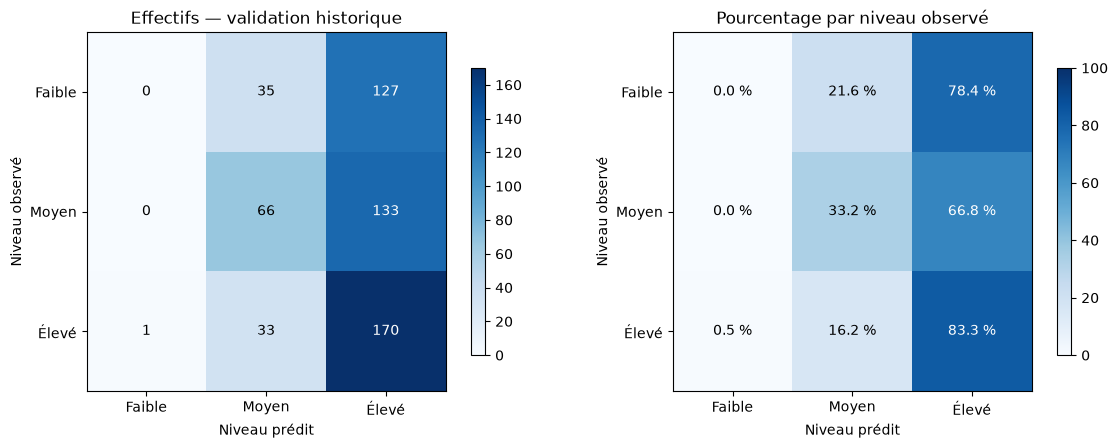

Seuils de montant (€) : [1034.03       1678.03666667]
        Faible  Moyen  Élevé
Faible       0     35    127
Moyen        0     66    133
Élevé        1     33    170
Niveaux prédits : {'Faible': np.int64(1), 'Moyen': np.int64(134), 'Élevé': np.int64(430)}
MODÈLE FINAL : Gamma, Minimal_contrat_vehicule ; alpha = 0.1


In [24]:
from sklearn.metrics import confusion_matrix
thresholds=sinistres_apprentissage_final.montant_sinistre.quantile([1/3,2/3]).to_numpy()
assert thresholds[0]<thresholds[1]
labels=['Faible','Moyen','Élevé']
observed_levels=np.digitize(sinistres_validation_finale.montant_sinistre,thresholds,right=True)
predicted_levels=np.digitize(montants_validation_finaux,thresholds,right=True)
amount_matrix=confusion_matrix(observed_levels,predicted_levels,labels=[0,1,2])
assert amount_matrix.sum()==len(sinistres_validation_finale)
row_totals=amount_matrix.sum(axis=1,keepdims=True)
normalized_matrix=np.divide(100*amount_matrix,row_totals,out=np.zeros_like(amount_matrix,dtype=float),where=row_totals!=0)
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
for ax,values,title,percent in zip(axes,[amount_matrix,normalized_matrix],['Effectifs — validation historique','Pourcentage par niveau observé'],[False,True]):
    limit=100 if percent else max(1,values.max())
    im=ax.imshow(values,cmap='Blues',vmin=0,vmax=limit)
    ax.set_xticks(range(3),labels);ax.set_yticks(range(3),labels)
    ax.set(xlabel='Niveau prédit',ylabel='Niveau observé',title=title);ax.grid(False)
    for i in range(3):
        for j in range(3):
            text=f'{values[i,j]:.1f} %' if percent else str(values[i,j])
            ax.text(j,i,text,ha='center',va='center',color='white' if values[i,j]>.5*limit else 'black')
    fig.colorbar(im,ax=ax,shrink=.8)
plt.tight_layout();plt.show()
print('Seuils de montant (€) :',thresholds)
print(pd.DataFrame(amount_matrix,index=labels,columns=labels).to_string())
print('Niveaux prédits :',dict(zip(labels,np.bincount(predicted_levels,minlength=3))))
print('MODÈLE FINAL : Gamma,',config_finale['variante'],'; alpha =',config_finale['alpha'])